# Psychometric analyses by participant

This notebook computes the requested psychometric functions for every participant, one participant at a time. Each participant produces one figure with six subplots:

1. 2d psychometric function using `post_prob_pos` on the x-axis.
2. 2d psychometric function using `post_prob_1b_pos` on the x-axis.
3. Grouped psychometric function for `post_prob_pos_partsample3` grouped by `partsamples_arr_3_enc`.
4. Grouped psychometric function for `post_prob_pos_partsample5` grouped by `partsamples_arr_5_enc`.
5. Grouped psychometric function for `post_prob_pos_part2sample5` grouped by `part2samples_arr_5_enc`.
6. Grouped psychometric function for `post_prob_pos_part2sample7` grouped by `part2samples_arr_7_enc`.


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt

from scipy.optimize import minimize_scalar
from scipy.special import expit, logit
from scipy.stats import norm


In [4]:
DATA_ROOT = Path("data/Murphy2021/raw")
if not DATA_ROOT.exists():
    DATA_ROOT = Path("~/Documents/academic/data/Murphy2021/raw").expanduser()

INCLUDE_TRAINING = False
PARTICIPANTS = None  # Set to a list like ["DCB"] to run a subset.

mean_neg, mean_pos = -17, 17
std = 29
P0 = np.array([[0.5], [0.5]])


## Loading helpers

In [5]:
def load_mat(path):
    """Load a MATLAB .mat file and drop scipy's private metadata keys."""
    mat = sio.loadmat(path, squeeze_me=True, struct_as_record=False)
    return {key: value for key, value in mat.items() if not key.startswith("__")}


def matlab_value_to_python(value):
    """Convert MATLAB scalar/array/struct values into notebook-friendly Python objects."""
    if hasattr(value, "_fieldnames"):
        return {field: matlab_value_to_python(getattr(value, field)) for field in value._fieldnames}

    if isinstance(value, np.ndarray):
        if value.ndim == 0:
            return matlab_value_to_python(value.item())
        return value.tolist()

    if isinstance(value, np.generic):
        return value.item()

    return value


def flatten_dict(d, prefix=""):
    """Flatten nested metadata dictionaries into dot-separated columns."""
    rows = {}
    for key, value in d.items():
        name = f"{prefix}.{key}" if prefix else key
        if isinstance(value, dict):
            rows.update(flatten_dict(value, name))
        else:
            rows[name] = value
    return rows


def parse_subject_session_block(path):
    """Read participant/session/block from file names like DCB_1_1.mat."""
    parts = path.stem.split("_")
    block = int(parts[-1])
    session_number = int(parts[-2])
    participant_id = "_".join(parts[:-2])
    return participant_id, session_number, block


def discover_participants(data_root=DATA_ROOT, participants=PARTICIPANTS):
    if participants is not None:
        return list(participants)
    return sorted(path.name for path in data_root.iterdir() if path.is_dir())


In [6]:
def load_subject_behavior(subject_folder, data_root=DATA_ROOT, include_training=INCLUDE_TRAINING):
    subject_dir = data_root / subject_folder
    session_dirs = sorted(
        path
        for path in subject_dir.iterdir()
        if path.is_dir() and (include_training or path.name != "Training")
    )

    behav_columns = [
        "correct_response_dist",
        "response",
        "accuracy",
        "rt_from_go_cue",
        "trial_onset_ptb",
        "fixation_break_count",
    ]

    trial_frames = []
    sample_frames = []
    block_metadata_rows = []

    for session_dir in session_dirs:
        behaviour_dir = session_dir / "Behaviour"
        sample_seqs_dir = session_dir / "Sample_seqs"

        for behav_path in sorted(behaviour_dir.glob("*.mat")):
            sample_path = sample_seqs_dir / behav_path.name
            if not sample_path.exists():
                raise FileNotFoundError(f"Missing matching Sample_seqs file for {behav_path}")

            participant_id, session_number, block = parse_subject_session_block(behav_path)
            block_id = f"{participant_id}_S{session_number}_B{block}"

            behav_mat = load_mat(behav_path)
            sample_mat = load_mat(sample_path)

            behav = np.asarray(behav_mat["Behav"])
            t_refresh = np.asarray(behav_mat["tRefresh"])
            stim_in = np.asarray(sample_mat["stimIn"])
            distseqs = np.asarray(sample_mat["distseqs"])
            pswitch = np.asarray(sample_mat["pswitch"])

            if behav.ndim != 2 or behav.shape[1] != len(behav_columns):
                raise ValueError(f"Unexpected Behav shape in {behav_path}: {behav.shape}")

            n_planned_trials, n_samples = stim_in.shape
            n_trials = behav.shape[0]
            if n_trials > n_planned_trials:
                raise ValueError(
                    f"More behavioral trials than stimulus rows for {block_id}: "
                    f"Behav has {n_trials}, stimIn has {n_planned_trials}"
                )

            stim_in_completed = stim_in[:n_trials]
            distseqs_completed = distseqs[:n_trials]
            pswitch_completed = pswitch[:n_trials]
            t_refresh_completed = t_refresh[:n_trials]

            trial_df = pd.DataFrame(behav, columns=behav_columns)
            trial_df.insert(0, "trial", np.arange(1, n_trials + 1))
            trial_df.insert(0, "block", block)
            trial_df.insert(0, "session", session_number)
            trial_df.insert(0, "session_label", session_dir.name)
            trial_df.insert(0, "participant_id", participant_id)
            trial_df.insert(0, "subject_folder", subject_dir.name)
            trial_df.insert(0, "block_id", block_id)

            trial_df["n_presented_samples"] = np.sum(~np.isnan(stim_in_completed), axis=1)
            trial_df["final_sample_location"] = stim_in_completed[
                np.arange(n_trials), trial_df["n_presented_samples"].to_numpy() - 1
            ]
            trial_frames.append(trial_df)

            sample_df = pd.DataFrame(
                {
                    "block_id": np.repeat(block_id, n_trials * n_samples),
                    "subject_folder": np.repeat(subject_dir.name, n_trials * n_samples),
                    "participant_id": np.repeat(participant_id, n_trials * n_samples),
                    "session_label": np.repeat(session_dir.name, n_trials * n_samples),
                    "session": np.repeat(session_number, n_trials * n_samples),
                    "block": np.repeat(block, n_trials * n_samples),
                    "trial": np.repeat(np.arange(1, n_trials + 1), n_samples),
                    "sample": np.tile(np.arange(1, n_samples + 1), n_trials),
                    "stim_location_deg": stim_in_completed.reshape(-1),
                    "generative_dist": distseqs_completed.reshape(-1),
                    "distribution_switch": pswitch_completed.reshape(-1),
                    "sample_onset_from_trial_s": t_refresh_completed.reshape(-1),
                }
            )
            sample_frames.append(sample_df)

            metadata = {
                "block_id": block_id,
                "subject_folder": subject_dir.name,
                "participant_id": participant_id,
                "session_label": session_dir.name,
                "session": session_number,
                "block": block,
                "n_completed_trials": n_trials,
                "n_planned_trials": n_planned_trials,
                "has_incomplete_behaviour": n_trials != n_planned_trials,
                "n_samples": n_samples,
                "behaviour_file": str(behav_path),
                "sample_seqs_file": str(sample_path),
                "pshort": matlab_value_to_python(sample_mat["pshort"]),
            }
            for struct_name in ["gen", "timing", "stim"]:
                metadata.update(flatten_dict({struct_name: matlab_value_to_python(sample_mat[struct_name])}))
            block_metadata_rows.append(metadata)

    trials_df = pd.concat(trial_frames, ignore_index=True)
    samples_df = pd.concat(sample_frames, ignore_index=True)
    block_metadata_df = pd.DataFrame(block_metadata_rows)
    return trials_df, samples_df, block_metadata_df


## Psychometric and posterior helpers

In [7]:
def psychometric_choice_probability_by_group(
    trials_df,
    variable,
    grouping_variable,
    response_col="response",
    sort=True,
    return_counts=False,
):
    """Estimate P(choose positive source) for each discrete grouping value."""
    trial_data = trials_df.copy()
    variable_values = trial_data[variable].to_numpy(dtype=float)
    group_values = trial_data[grouping_variable].to_numpy()
    responses = trial_data[response_col].to_numpy(dtype=float)

    finite_mask = np.isfinite(variable_values) & np.isfinite(responses) & pd.notna(group_values)
    grouped_data = pd.DataFrame(
        {
            "variable": variable_values[finite_mask],
            "group": group_values[finite_mask],
            "response": responses[finite_mask],
        }
    )
    if grouped_data.empty:
        raise ValueError("No finite trials remain after applying filters")

    group_order = []
    psychometric_values = []
    choice_probabilities = []
    counts = []
    for group_value, group_df in grouped_data.groupby("group", sort=sort, dropna=True):
        unique_variable_values = group_df["variable"].unique()
        if len(unique_variable_values) != 1:
            raise ValueError(
                f"`variable` must have exactly one value within each group; "
                f"group {group_value!r} has {len(unique_variable_values)} values"
            )
        group_order.append(group_value)
        psychometric_values.append(unique_variable_values[0])
        choice_probabilities.append(np.mean(group_df["response"].to_numpy() == 1))
        counts.append(len(group_df))

    output = (
        np.asarray(choice_probabilities, dtype=float),
        np.asarray(psychometric_values, dtype=float),
        np.asarray(group_order),
    )
    if return_counts:
        output = (*output, np.asarray(counts, dtype=int))
    return output


def psychometric_choice_probability_2d(
    trials_df,
    variables,
    bins=None,
    n_bins=10,
    response_col="response",
    return_bins=False,
    return_counts=False,
):
    """Estimate P(choose positive source) in bins of two continuous variables."""
    x_values = trials_df[variables[0]].to_numpy(dtype=float)
    y_values = trials_df[variables[1]].to_numpy(dtype=float)
    responses = trials_df[response_col].to_numpy(dtype=float)

    finite_mask = np.isfinite(x_values) & np.isfinite(y_values) & np.isfinite(responses)
    x_values = x_values[finite_mask]
    y_values = y_values[finite_mask]
    responses = responses[finite_mask]
    if x_values.size == 0:
        raise ValueError("No finite trials remain after applying filters")

    def make_bins(values, bin_spec, default_n_bins):
        if bin_spec is None or np.isscalar(bin_spec):
            n = int(default_n_bins if bin_spec is None else bin_spec)
            lo, hi = np.nanmin(values), np.nanmax(values)
            if lo == hi:
                half_width = 0.5 if lo == 0 else abs(lo) * 0.05
                lo, hi = lo - half_width, hi + half_width
            edges = np.linspace(lo, hi, n + 1)
        else:
            edges = np.asarray(bin_spec, dtype=float)
        if edges.ndim != 1 or edges.size < 2 or np.any(np.diff(edges) <= 0):
            raise ValueError("bins must be increasing bin edges or a positive integer")
        return edges

    if bins is None:
        x_bin_spec, y_bin_spec = None, None
    elif np.isscalar(bins):
        x_bin_spec, y_bin_spec = bins, bins
    elif isinstance(bins, tuple) and len(bins) == 2:
        x_bin_spec, y_bin_spec = bins
    else:
        x_bin_spec, y_bin_spec = bins, bins

    if np.isscalar(n_bins):
        x_n_bins, y_n_bins = int(n_bins), int(n_bins)
    else:
        x_n_bins, y_n_bins = n_bins

    x_bins = make_bins(x_values, x_bin_spec, x_n_bins)
    y_bins = make_bins(y_values, y_bin_spec, y_n_bins)
    x_centers = (x_bins[:-1] + x_bins[1:]) / 2
    y_centers = (y_bins[:-1] + y_bins[1:]) / 2

    x_bin_index = np.digitize(x_values, x_bins, right=False) - 1
    y_bin_index = np.digitize(y_values, y_bins, right=False) - 1
    x_bin_index[x_values == x_bins[-1]] = len(x_bins) - 2
    y_bin_index[y_values == y_bins[-1]] = len(y_bins) - 2

    choice_probabilities = np.full((len(x_centers), len(y_centers)), np.nan)
    counts = np.zeros_like(choice_probabilities, dtype=int)
    for x_idx in range(len(x_centers)):
        for y_idx in range(len(y_centers)):
            in_bin = (x_bin_index == x_idx) & (y_bin_index == y_idx)
            counts[x_idx, y_idx] = np.count_nonzero(in_bin)
            if counts[x_idx, y_idx] > 0:
                choice_probabilities[x_idx, y_idx] = np.mean(responses[in_bin] == 1)

    x_center_grid, y_center_grid = np.meshgrid(x_centers, y_centers, indexing="ij")
    bin_centers = np.stack((x_center_grid, y_center_grid), axis=-1)
    output = (bin_centers, choice_probabilities)
    if return_counts:
        output = (*output, counts)
    if return_bins:
        output = (*output, x_bins, y_bins)
    return output


In [8]:
def finite_logit(values, eps=1e-12):
    return logit(np.clip(values, eps, 1 - eps))


def P_source_g_samples(samples_arr, mean_neg, mean_pos, std, h, P0, window_size=None):
    P_sample_g_neg = norm(loc=mean_neg, scale=std)
    P_sample_g_pos = norm(loc=mean_pos, scale=std)
    Lneg = P_sample_g_neg.pdf(samples_arr)
    Lpos = P_sample_g_pos.pdf(samples_arr)
    L = np.stack((Lneg, Lpos), axis=1).T
    H = np.array([[1 - h, h], [h, 1 - h]])
    P = P0.copy()
    if window_size is not None:
        L = L[:, -window_size:]
    for ii in range(L.shape[1]):
        P = L[:, ii][:, np.newaxis] * (H @ P)
    return P / P.sum(axis=0, keepdims=True)


def partition_normal(norm_obj, cuts):
    cuts = np.asarray(cuts)
    cdf_values = norm_obj.cdf(cuts)
    return np.diff(np.concatenate(([0], cdf_values, [1])))


def compute_partitioned_Ixy(dist_neg, dist_pos, p_Y, cuts):
    p_XgY0 = partition_normal(dist_neg, cuts)
    p_XgY1 = partition_normal(dist_pos, cuts)
    p_XgY = np.stack((p_XgY0, p_XgY1), axis=1)
    p_XY = p_Y * p_XgY
    p_X = p_XY.sum(axis=1, keepdims=True)
    return np.nansum(p_XY * np.log(p_XY / (p_X * p_Y)))


def map_to_partition(sample_arr, cuts):
    sample_arr = np.asarray(sample_arr)
    bin_edges = np.concatenate(([-np.inf], np.asarray(cuts), [np.inf]))
    return np.digitize(sample_arr, bin_edges) - 1


def P_source_g_partsamples(partsamples_arr, mean_neg, mean_pos, std, cuts, h, P0, window_size=None):
    P_partsamples_g_neg = partition_normal(norm(loc=mean_neg, scale=std), cuts)
    P_partsamples_g_pos = partition_normal(norm(loc=mean_pos, scale=std), cuts)
    Lneg = P_partsamples_g_neg[partsamples_arr]
    Lpos = P_partsamples_g_pos[partsamples_arr]
    L = np.stack((Lneg, Lpos), axis=1).T
    H = np.array([[1 - h, h], [h, 1 - h]])
    P = P0.copy()
    if window_size is not None:
        L = L[:, -window_size:]
    for ii in range(L.shape[1]):
        P = L[:, ii][:, np.newaxis] * (H @ P)
    return P / P.sum(axis=0, keepdims=True)


def encode_partition_sequence(arr):
    if not isinstance(arr, (list, np.ndarray)):
        return np.nan
    arr = np.asarray(arr, dtype=int)
    return int(np.sum(10 ** np.arange(len(arr) - 1, -1, -1) * arr))


def last_k_partition_sequence(arr, k):
    if isinstance(arr, (list, np.ndarray)) and len(arr) >= k:
        return np.asarray(arr)[-k:]
    return np.nan


## Participant preparation

In [9]:
def identify_hazard_column(block_metadata_df):
    h_col_candidates = [c for c in ["gen.h", "gen.H", "h", "H"] if c in block_metadata_df.columns]
    if h_col_candidates:
        return h_col_candidates[0]
    h_like_cols = [c for c in block_metadata_df.columns if c.lower().endswith(".h") or c.lower() == "h"]
    if len(h_like_cols) != 1:
        raise KeyError(f"Could not uniquely identify hazard-rate column. Candidates: {h_like_cols}")
    return h_like_cols[0]


def compute_optimal_four_partition_cuts():
    dist_neg = norm(loc=mean_neg, scale=std)
    dist_pos = norm(loc=mean_pos, scale=std)

    def obj_function(cut):
        return -compute_partitioned_Ixy(dist_neg, dist_pos, np.array([[0.5, 0.5]]), [-cut, 0, cut])

    result = minimize_scalar(obj_function, bounds=(0, 89), method="bounded")
    cut = result.x
    return [-cut, 0, cut]


def add_partitioned_posterior(trials_df, h_by_block, source_col, suffix, cuts, k):
    seq_col = f"{source_col}_{k}"
    enc_col = f"{source_col}_{k}_enc"
    prob_col = f"post_prob_pos_{suffix}{k}"

    trials_df[seq_col] = trials_df[source_col].apply(lambda arr: last_k_partition_sequence(arr, k))
    trials_df[prob_col] = trials_df.apply(
        lambda row: float(
            P_source_g_partsamples(
                np.asarray(row[seq_col], dtype=int),
                mean_neg,
                mean_pos,
                std,
                cuts,
                float(h_by_block.loc[row["block_id"]]),
                P0,
            )[1, 0]
        )
        if isinstance(row[seq_col], (list, np.ndarray))
        else np.nan,
        axis=1,
    )
    trials_df[enc_col] = trials_df[seq_col].apply(encode_partition_sequence)
    return prob_col, enc_col


def prepare_subject_data(subject_folder):
    trials_df, samples_df, block_metadata_df = load_subject_behavior(subject_folder)

    samples_df.loc[samples_df["stim_location_deg"] == -89.99, "stim_location_deg"] = -90.0
    samples_df.loc[samples_df["stim_location_deg"] == 89.99, "stim_location_deg"] = 90.0

    dist_neg = norm(loc=mean_neg, scale=std)
    dist_pos = norm(loc=mean_pos, scale=std)
    samples_df["LLR_pos"] = np.log(dist_pos.pdf(samples_df["stim_location_deg"]) / dist_neg.pdf(samples_df["stim_location_deg"]))

    group_cols = ["session", "block", "trial"]
    samples_arr_by_trial = (
        samples_df.sort_values("sample")
        .groupby(group_cols)["stim_location_deg"]
        .apply(lambda s: s.dropna().to_numpy())
    )
    trials_df["samples_arr"] = pd.MultiIndex.from_frame(trials_df[group_cols]).map(samples_arr_by_trial)

    llr_arr_by_trial = (
        samples_df.sort_values("sample")
        .groupby(group_cols)["LLR_pos"]
        .apply(lambda s: s.dropna().to_numpy())
    )
    trials_df["LLR_arr"] = pd.MultiIndex.from_frame(trials_df[group_cols]).map(llr_arr_by_trial)

    h_col = identify_hazard_column(block_metadata_df)
    h_by_block = block_metadata_df.set_index("block_id")[h_col]

    trials_df["post_prob_pos"] = trials_df.apply(
        lambda row: float(
            P_source_g_samples(
                np.asarray(row["samples_arr"], dtype=float),
                mean_neg,
                mean_pos,
                std,
                float(h_by_block.loc[row["block_id"]]),
                P0,
            )[1, 0]
        ),
        axis=1,
    )
    trials_df["post_prob_1b_pos"] = trials_df.apply(
        lambda row: float(
            P_source_g_samples(
                np.asarray(row["samples_arr"], dtype=float),
                mean_neg,
                mean_pos,
                std,
                float(h_by_block.loc[row["block_id"]]),
                P0,
                window_size=1,
            )[1, 0]
        ),
        axis=1,
    )
    trials_df["LPO_pos"] = finite_logit(trials_df["post_prob_pos"].to_numpy())
    trials_df["LPO_1b_pos"] = finite_logit(trials_df["post_prob_1b_pos"].to_numpy())

    cuts = compute_optimal_four_partition_cuts()
    trials_df["partsamples_arr"] = trials_df["samples_arr"].apply(lambda arr: map_to_partition(np.asarray(arr), cuts))
    add_partitioned_posterior(trials_df, h_by_block, "partsamples_arr", "partsample", cuts, 3)
    add_partitioned_posterior(trials_df, h_by_block, "partsamples_arr", "partsample", cuts, 5)

    cuts3 = [0]
    trials_df["part2samples_arr"] = trials_df["samples_arr"].apply(lambda arr: map_to_partition(np.asarray(arr), cuts3))
    add_partitioned_posterior(trials_df, h_by_block, "part2samples_arr", "part2sample", cuts3, 5)
    add_partitioned_posterior(trials_df, h_by_block, "part2samples_arr", "part2sample", cuts3, 7)

    return trials_df, samples_df, block_metadata_df


## Plotting

In [10]:
def counts_to_sizes(counts, min_size=20, max_size=140):
    counts = np.asarray(counts, dtype=float)
    if counts.size == 0 or np.nanmax(counts) <= 0:
        return np.full_like(counts, min_size, dtype=float)
    return min_size + (max_size - min_size) * counts / np.nanmax(counts)


# def scatter_2d_psychometric(ax, x_values, choice_prob, counts, title, xlabel):
#     mask = np.isfinite(x_values) & np.isfinite(choice_prob) & (counts > 0)
#     ax.scatter(
#         x_values[mask],
#         choice_prob[mask],
#         s=counts_to_sizes(counts[mask]),
#         c="k",
#         alpha=0.65,
#         edgecolors="none",
#     )
#     ax.set_title(title)
#     ax.set_xlabel(xlabel)
#     ax.set_ylabel("P(choice = positive)")
#     ax.set_ylim(-0.05, 1.05)

def scatter_2d_psychometric(ax, x_values, choice_prob, counts, title, xlabel):
    mask = np.isfinite(x_values) & np.isfinite(choice_prob) & (counts > 0)
    ax.scatter(
        x_values[mask],
        choice_prob[mask],
        s=80,
        c="k",
        alpha=counts[mask]/np.nanmax(counts[mask]),
        edgecolors="none",
    )
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("P(choice = positive)")
    ax.set_ylim(-0.05, 1.05)


# def scatter_grouped_psychometric(ax, trials_df, variable, grouping_variable, title):
#     p_RgX, p_YgX, codes, counts = psychometric_choice_probability_by_group(
#         trials_df,
#         variable,
#         grouping_variable,
#         response_col="response",
#         sort=True,
#         return_counts=True,
#     )
#     order = np.argsort(p_YgX)
#     ax.scatter(
#         p_YgX[order],
#         p_RgX[order],
#         s=counts_to_sizes(counts[order]),
#         c="k",
#         alpha=0.65,
#         edgecolors="none",
#     )
#     ax.set_title(title)
#     ax.set_xlabel(variable)
#     ax.set_ylabel("P(choice = positive)")
#     ax.set_ylim(-0.05, 1.05)

def scatter_grouped_psychometric(ax, trials_df, variable, grouping_variable, title):
    p_RgX, p_YgX, codes, counts = psychometric_choice_probability_by_group(
        trials_df,
        variable,
        grouping_variable,
        response_col="response",
        sort=True,
        return_counts=True,
    )
    order = np.argsort(p_YgX)
    ax.scatter(
        p_YgX[order],
        p_RgX[order],
        s=80,
        c="k",
        alpha=counts[order]/np.nanmax(counts[order]),
        edgecolors="none",
    )
    ax.set_title(title)
    ax.set_xlabel(variable)
    ax.set_ylabel("P(choice = positive)")
    ax.set_ylim(-0.05, 1.05)


def plot_subject_psychometrics(trials_df, participant_id):
    _, _, lpo_bins, lpo_1b_bins = psychometric_choice_probability_2d(
        trials_df,
        ("LPO_pos", "LPO_1b_pos"),
        n_bins=15,
        return_bins=True,
    )
    prob_bins = (expit(lpo_bins), expit(lpo_1b_bins))
    P_YgX_2d, P_RgX_2d, counts_2d = psychometric_choice_probability_2d(
        trials_df,
        ("post_prob_pos", "post_prob_1b_pos"),
        bins=prob_bins,
        return_counts=True,
    )

    fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
    fig.suptitle(f"Participant {participant_id}", fontsize=16)

    scatter_2d_psychometric(
        axes[0, 0],
        P_YgX_2d[:, :, 0],
        P_RgX_2d,
        counts_2d,
        "2d psychometric: post prob",
        "post_prob_pos bin center",
    )
    scatter_2d_psychometric(
        axes[0, 1],
        P_YgX_2d[:, :, 1],
        P_RgX_2d,
        counts_2d,
        "2d psychometric: 1-back post prob",
        "post_prob_1b_pos bin center",
    )

    scatter_grouped_psychometric(
        axes[0, 2],
        trials_df,
        "post_prob_pos_partsample3",
        "partsamples_arr_3_enc",
        "4-partition, last 3 samples",
    )
    scatter_grouped_psychometric(
        axes[1, 0],
        trials_df,
        "post_prob_pos_partsample5",
        "partsamples_arr_5_enc",
        "4-partition, last 5 samples",
    )
    scatter_grouped_psychometric(
        axes[1, 1],
        trials_df,
        "post_prob_pos_part2sample5",
        "part2samples_arr_5_enc",
        "2-partition, last 5 samples",
    )
    scatter_grouped_psychometric(
        axes[1, 2],
        trials_df,
        "post_prob_pos_part2sample7",
        "part2samples_arr_7_enc",
        "2-partition, last 7 samples",
    )

    return fig, axes


## Run all participants

In [11]:
participants = discover_participants()
participants
participants_no_2 = [p for p in participants if "2" not in p]
participants_no_2

['DCB',
 'DHB',
 'ECB',
 'EMB',
 'EXF',
 'EXG',
 'GSB',
 'HBC',
 'JTB',
 'KSV',
 'NIF',
 'OMF',
 'PDP',
 'QNV',
 'TFD',
 'TNB',
 'TSJ']

Processing DCB...


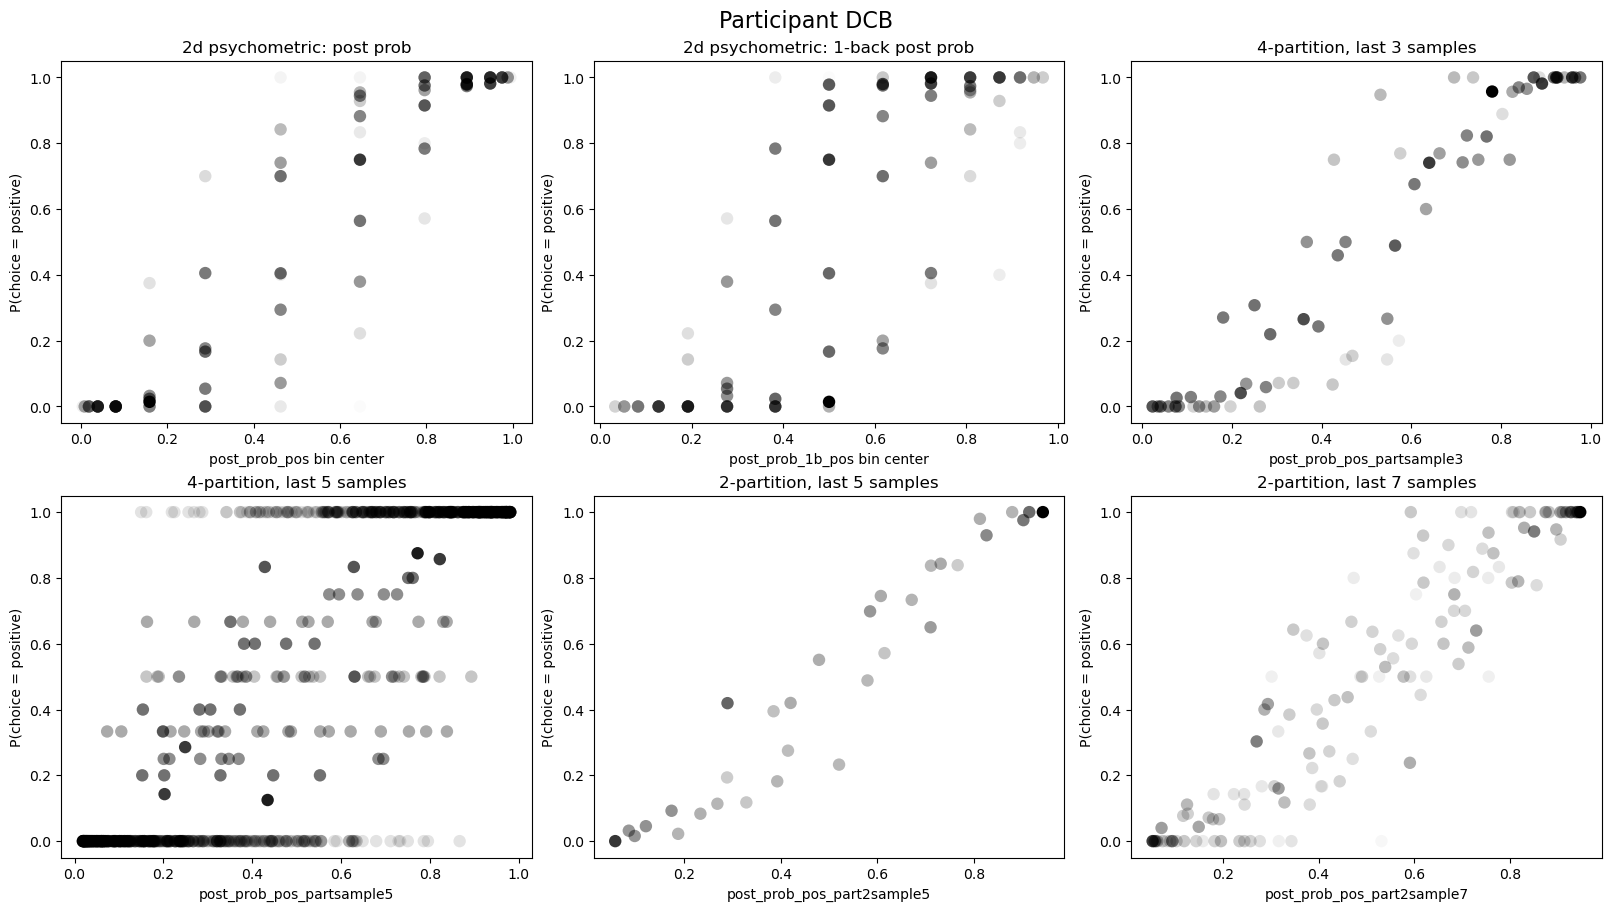

Processing DHB...


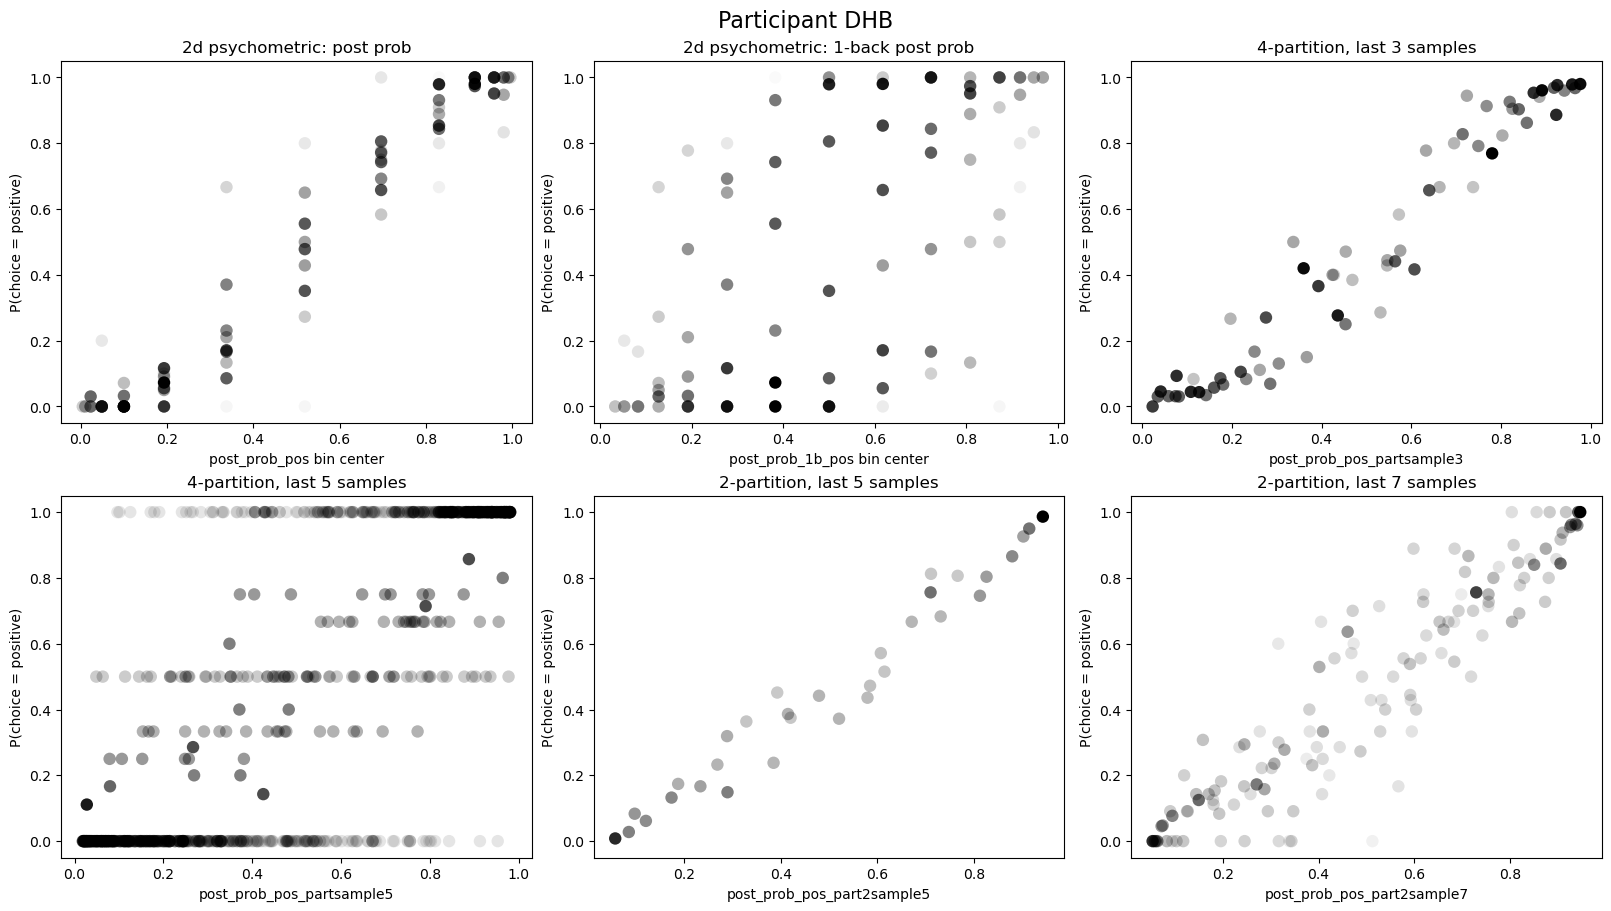

Processing ECB...


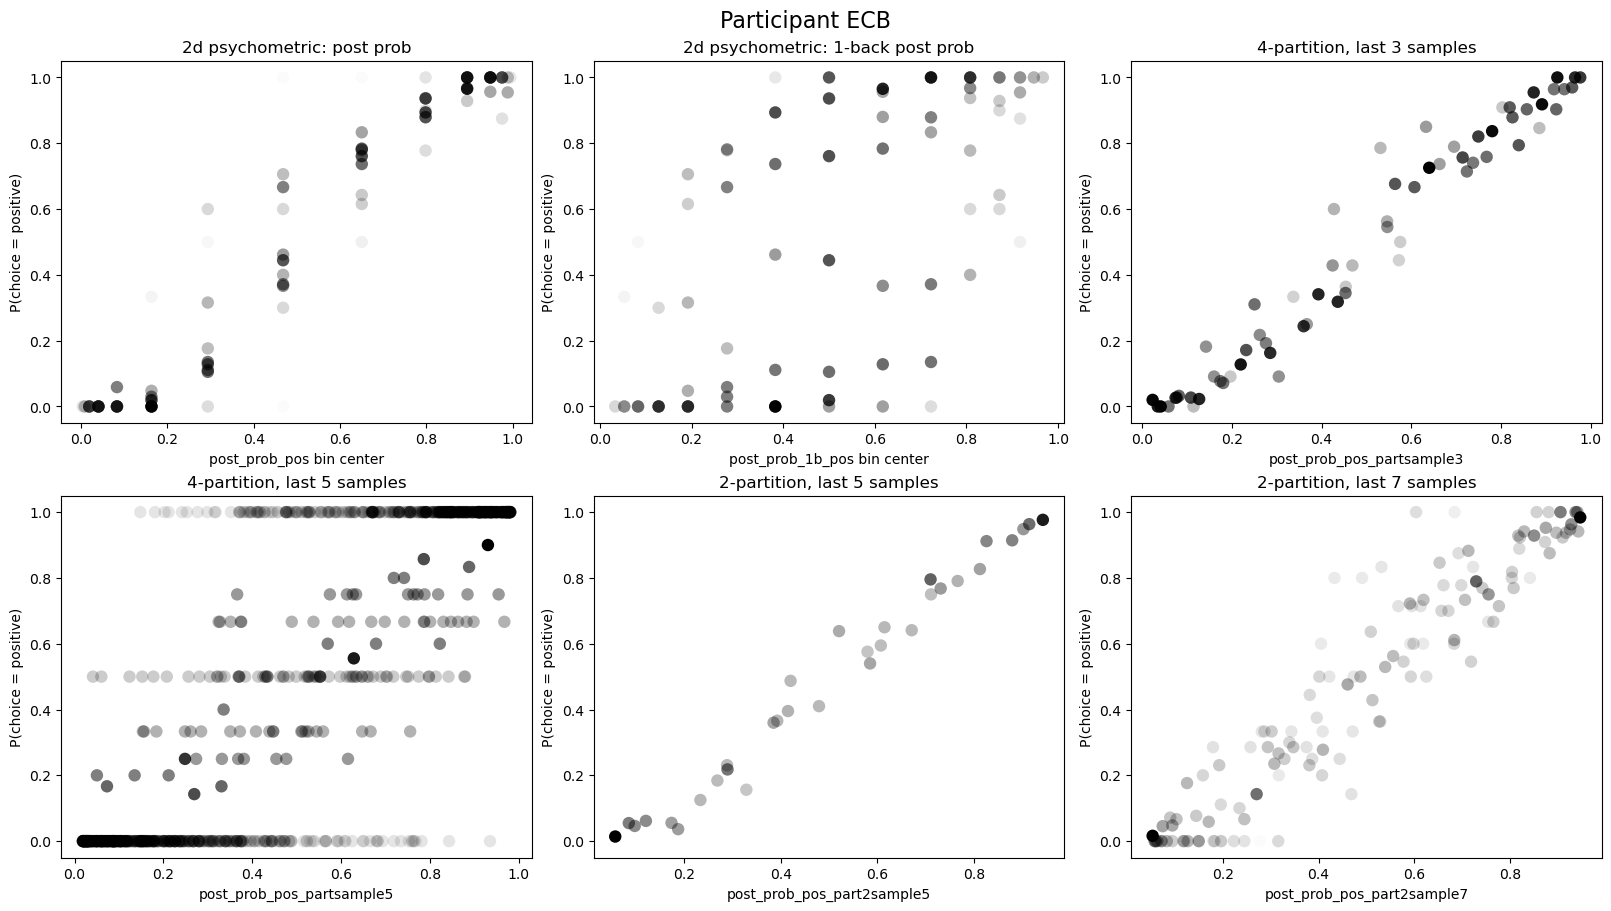

Processing EMB...


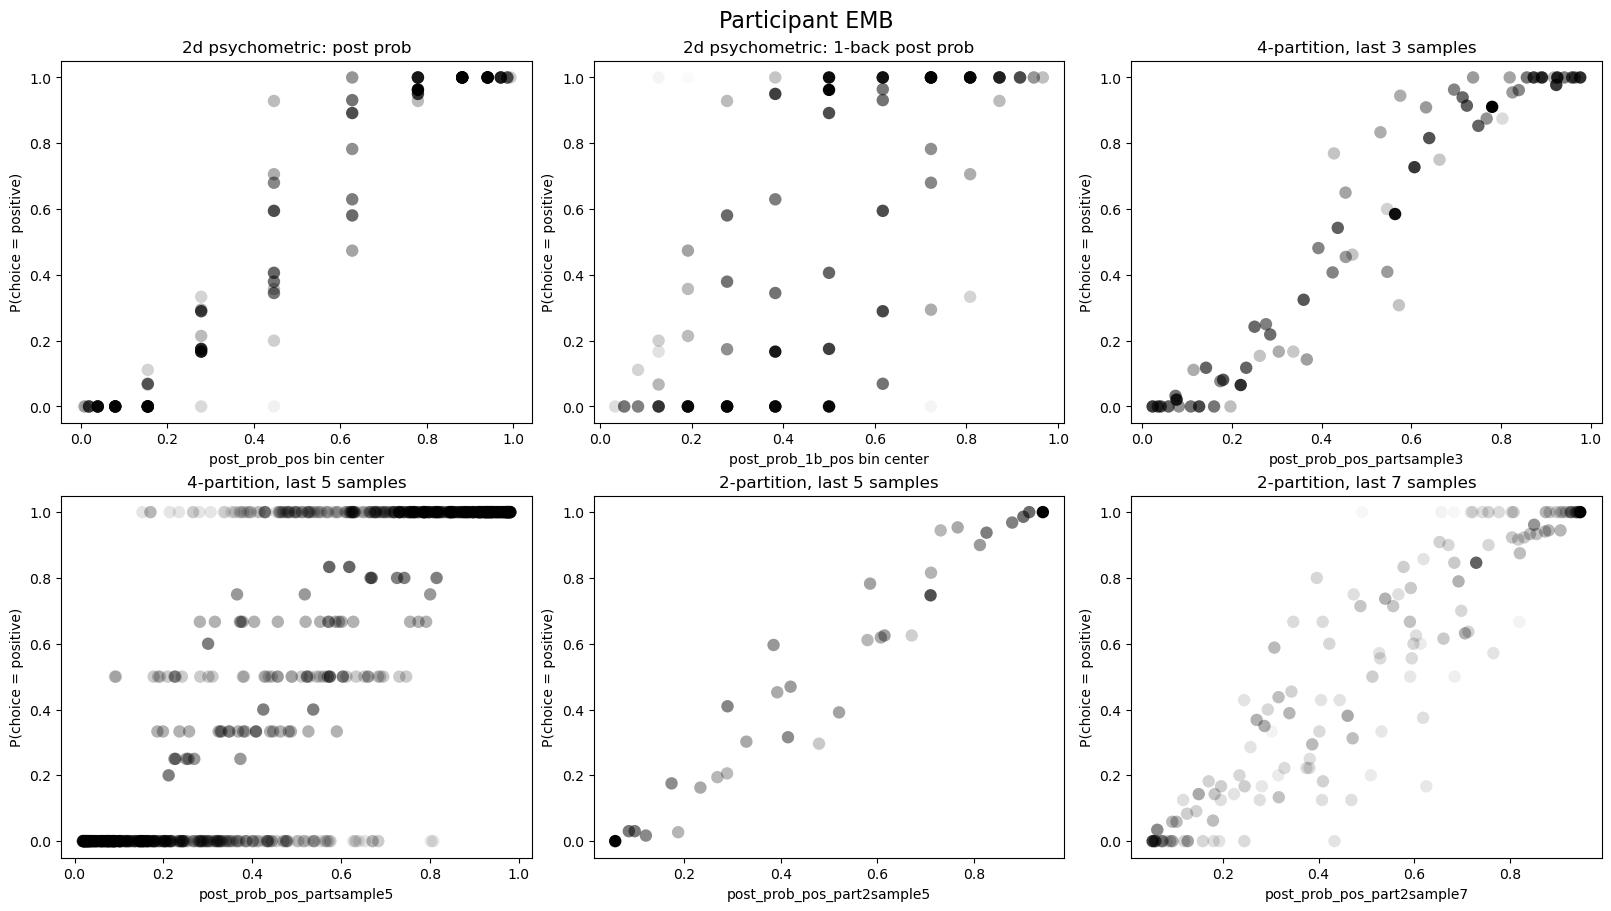

Processing EXF...


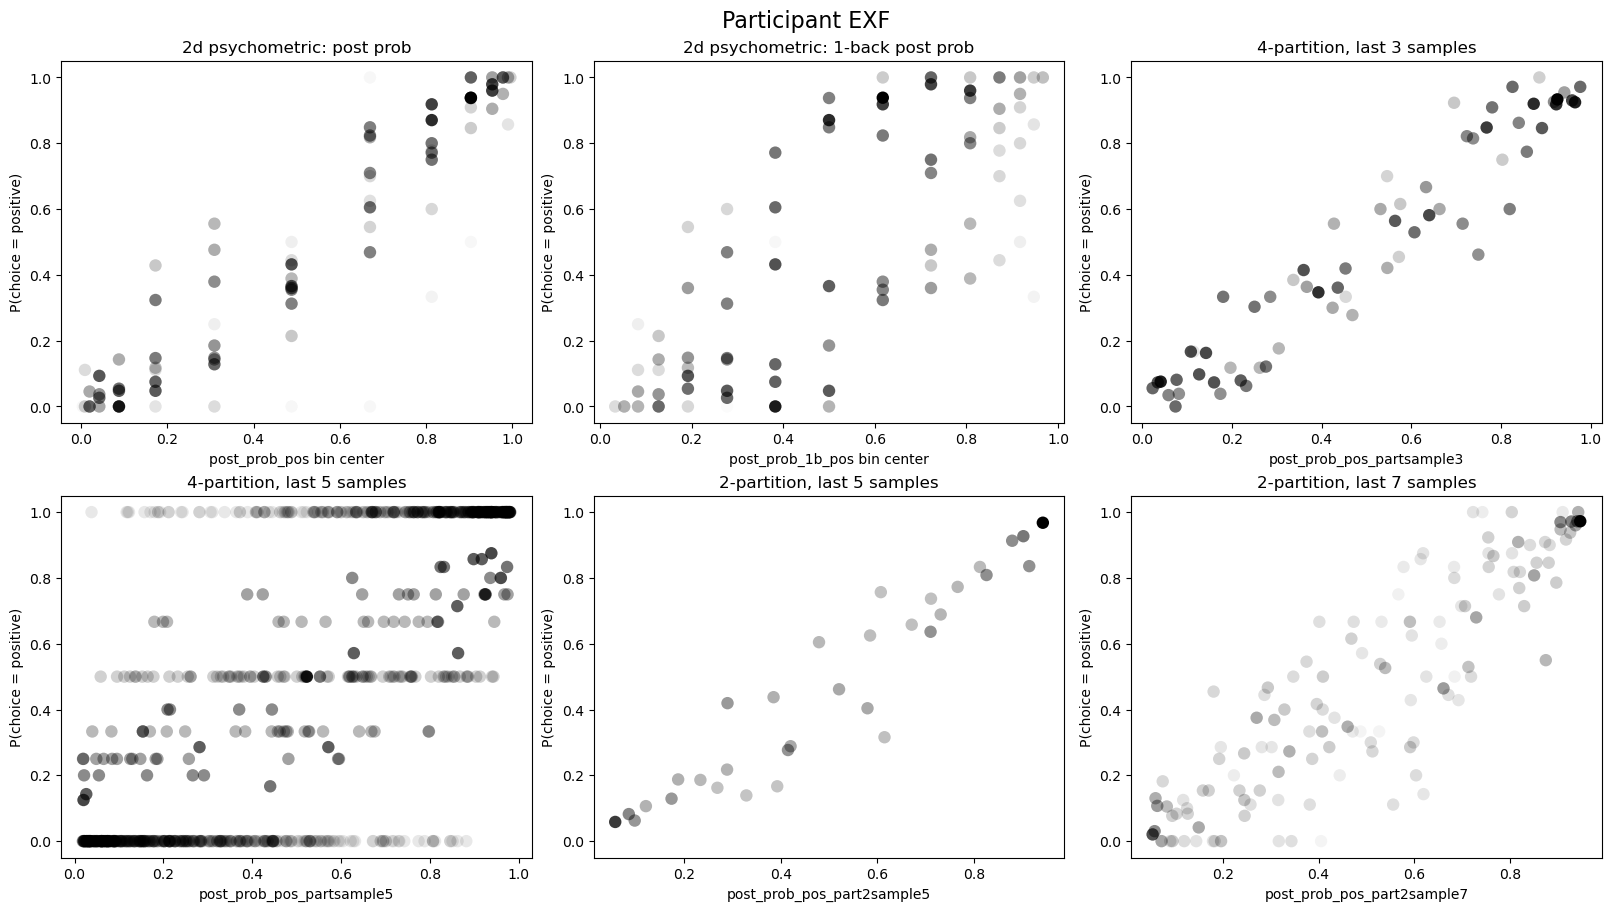

Processing EXG...


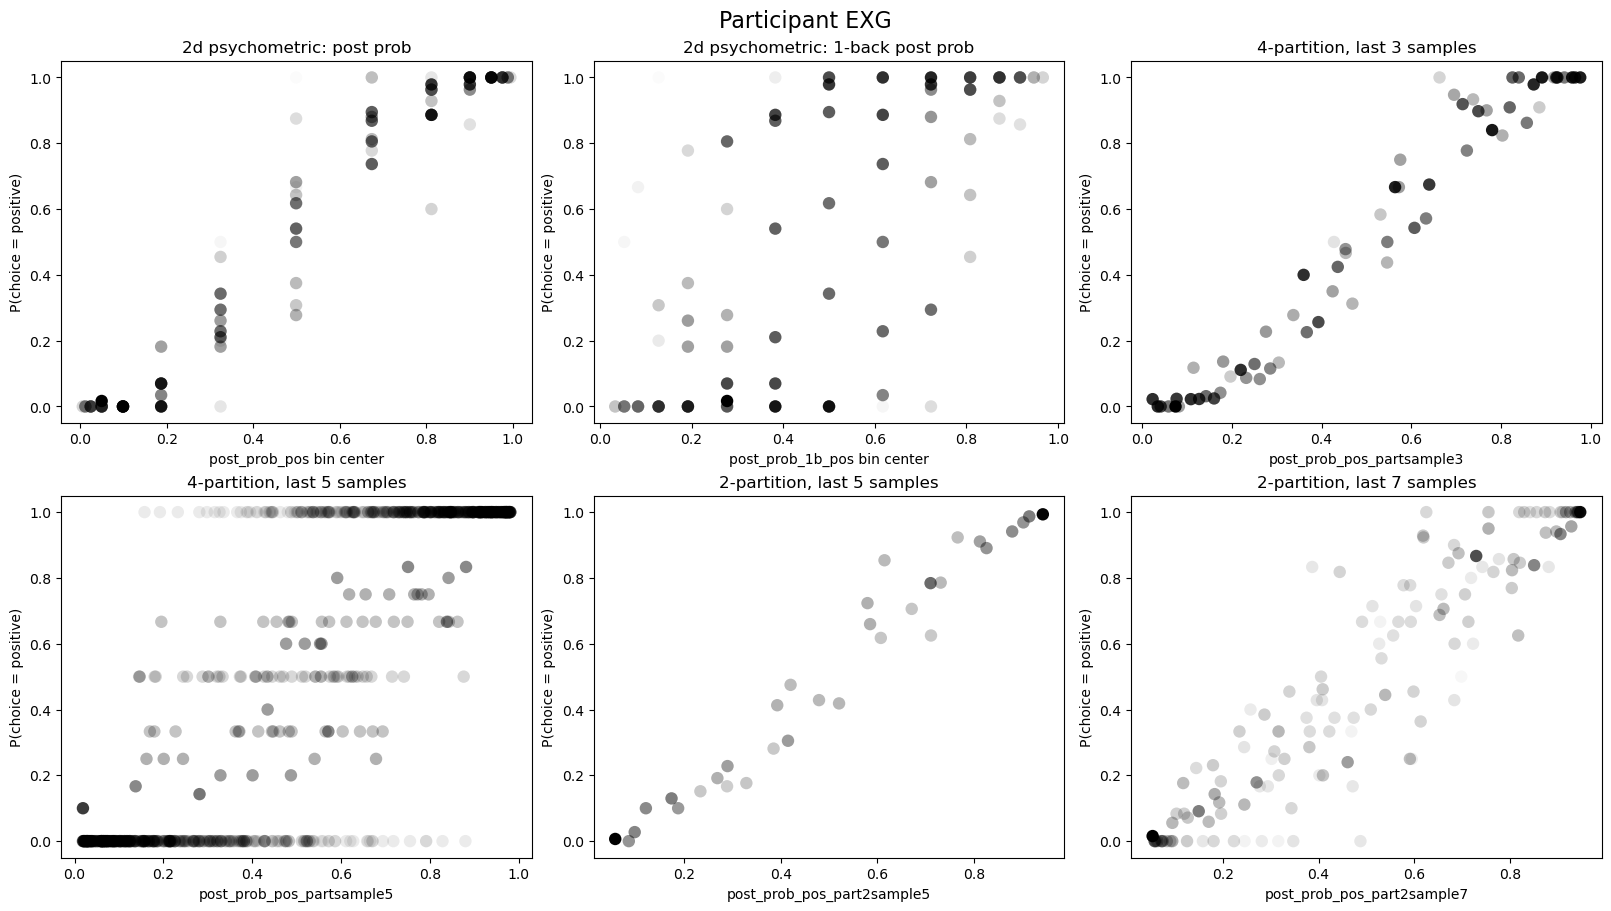

Processing GSB...


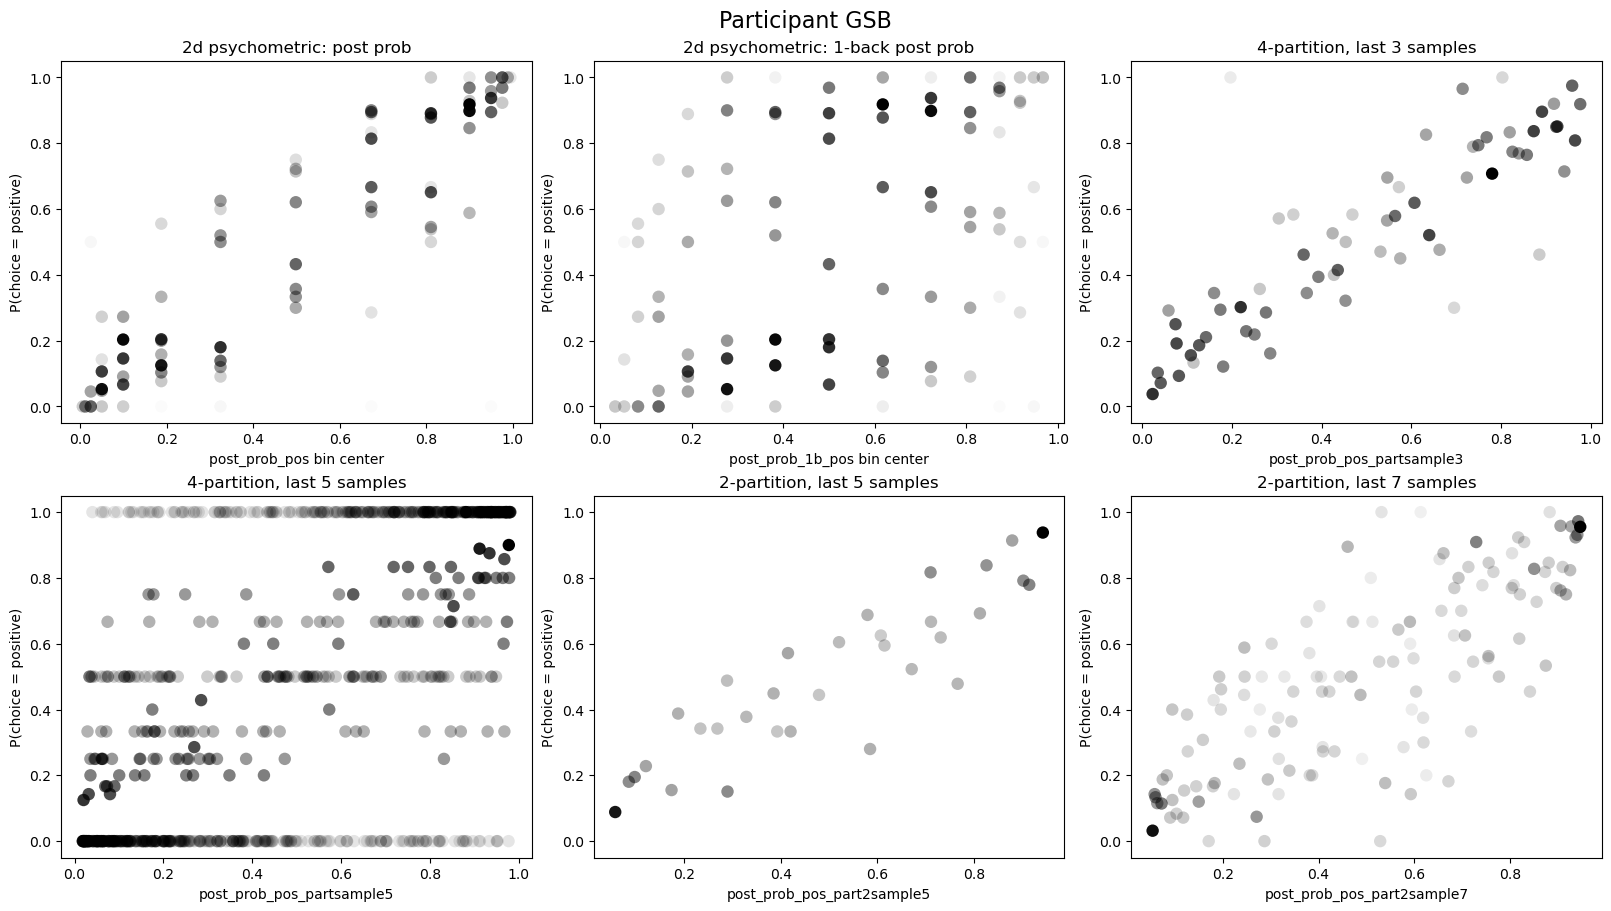

Processing HBC...


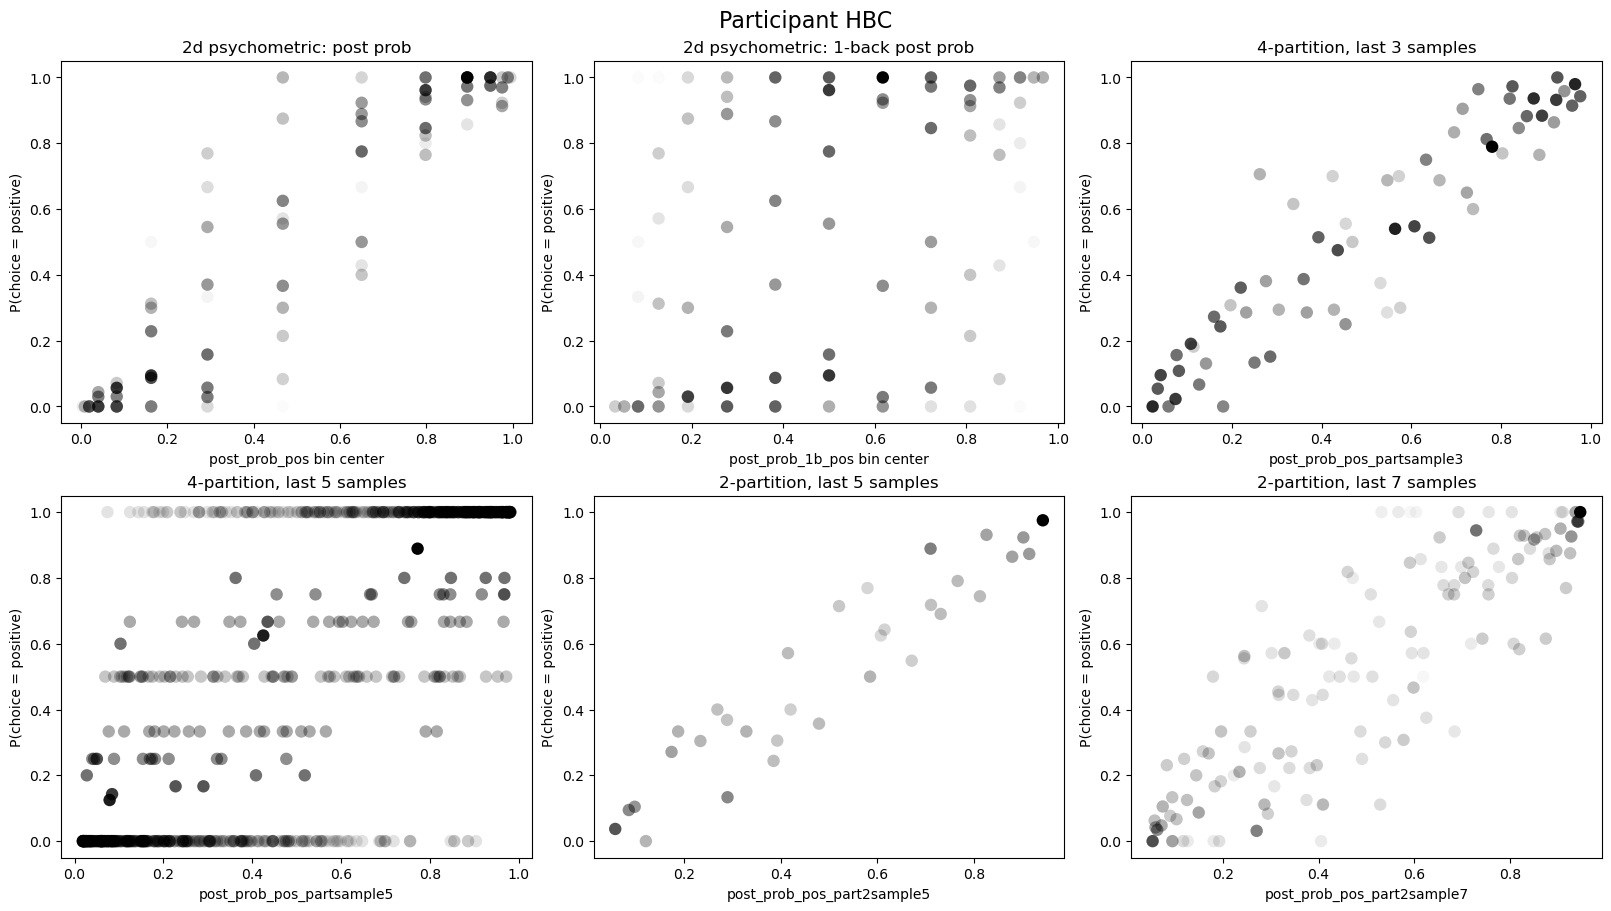

Processing JTB...


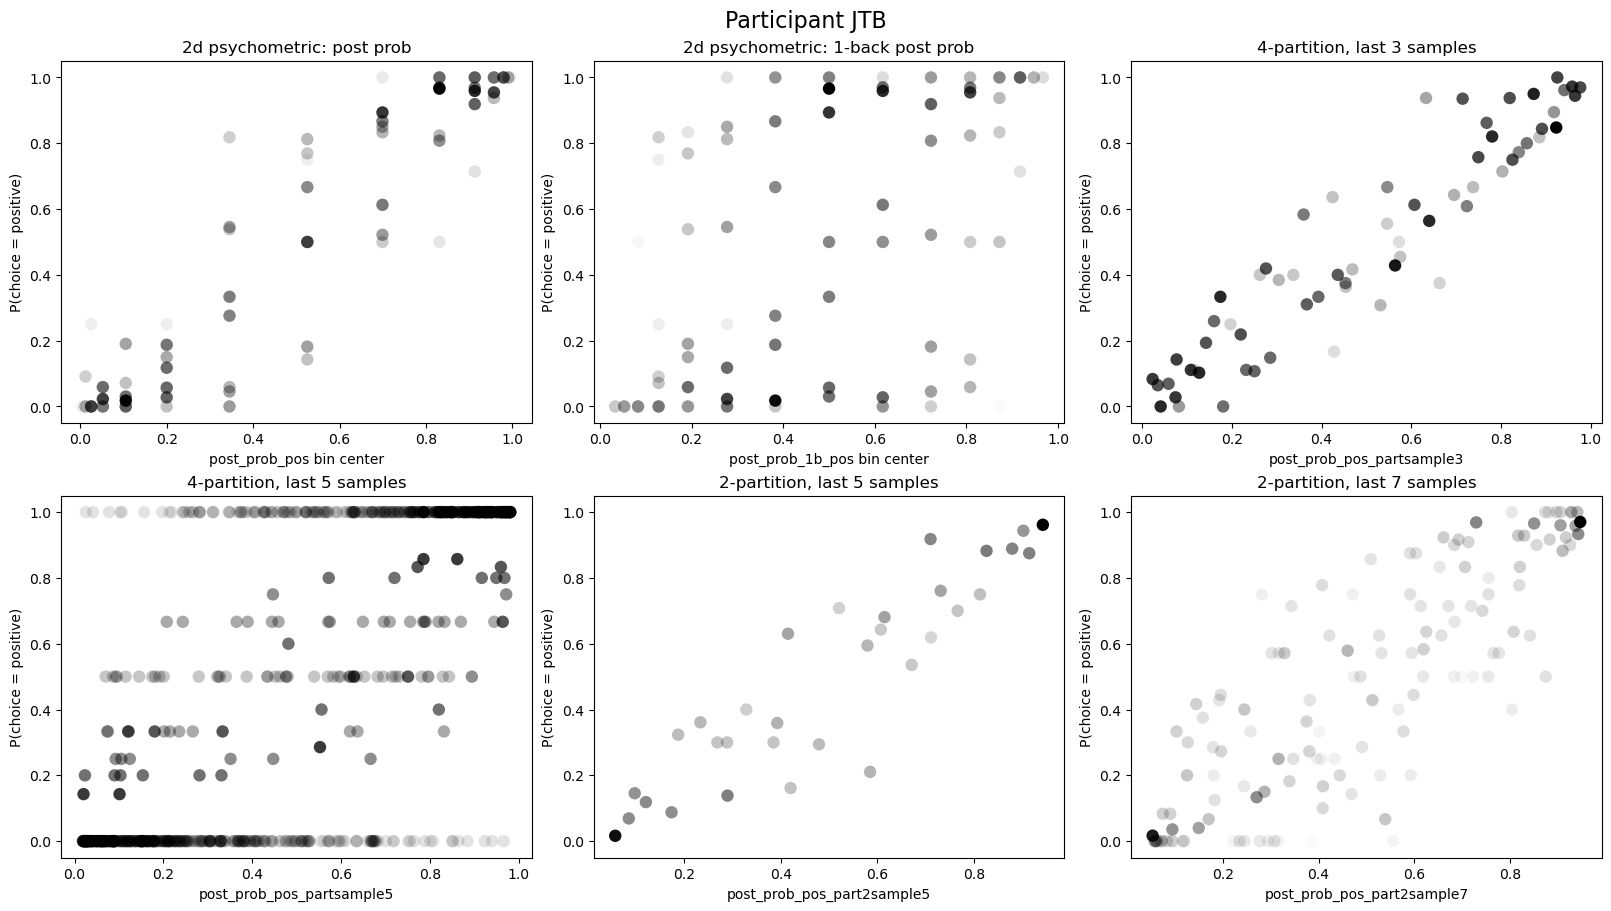

Processing KSV...


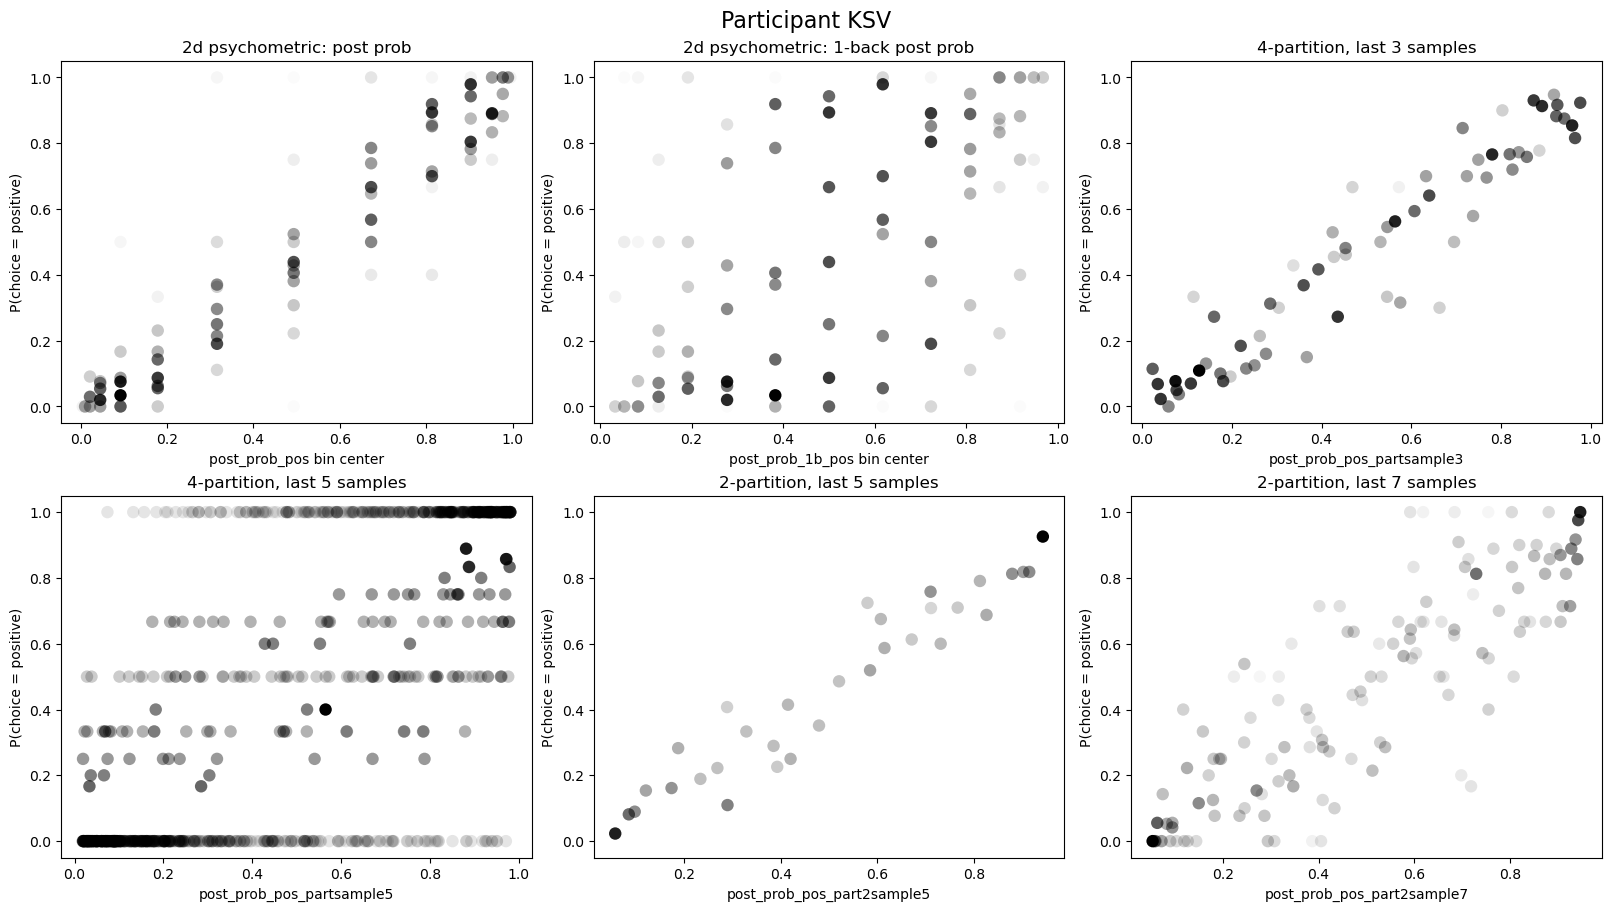

Processing NIF...


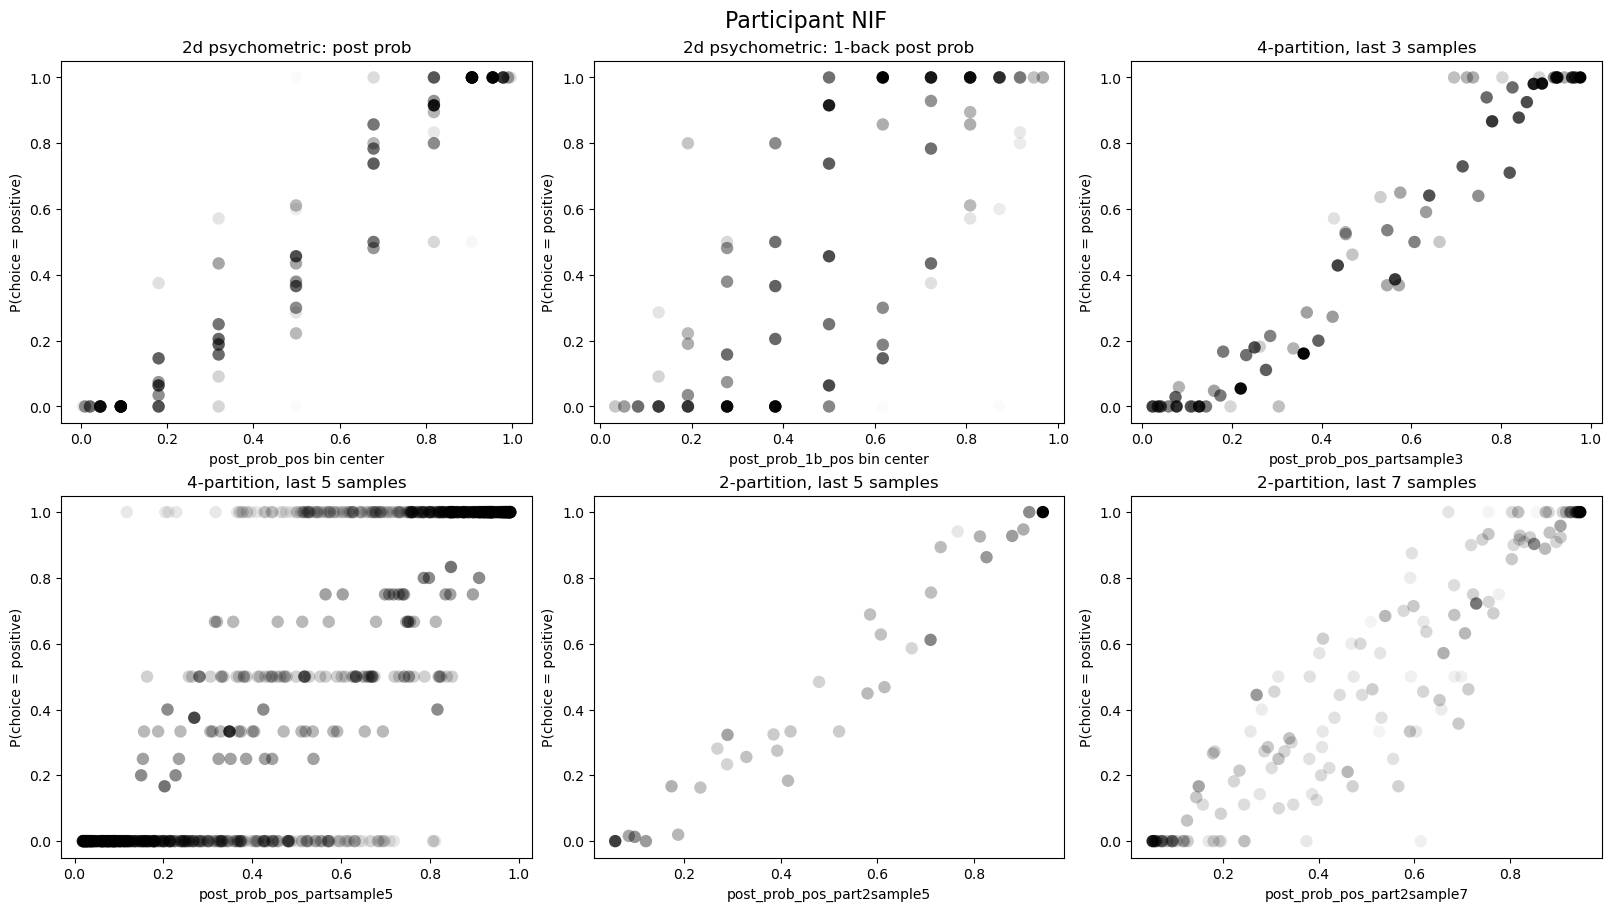

Processing OMF...


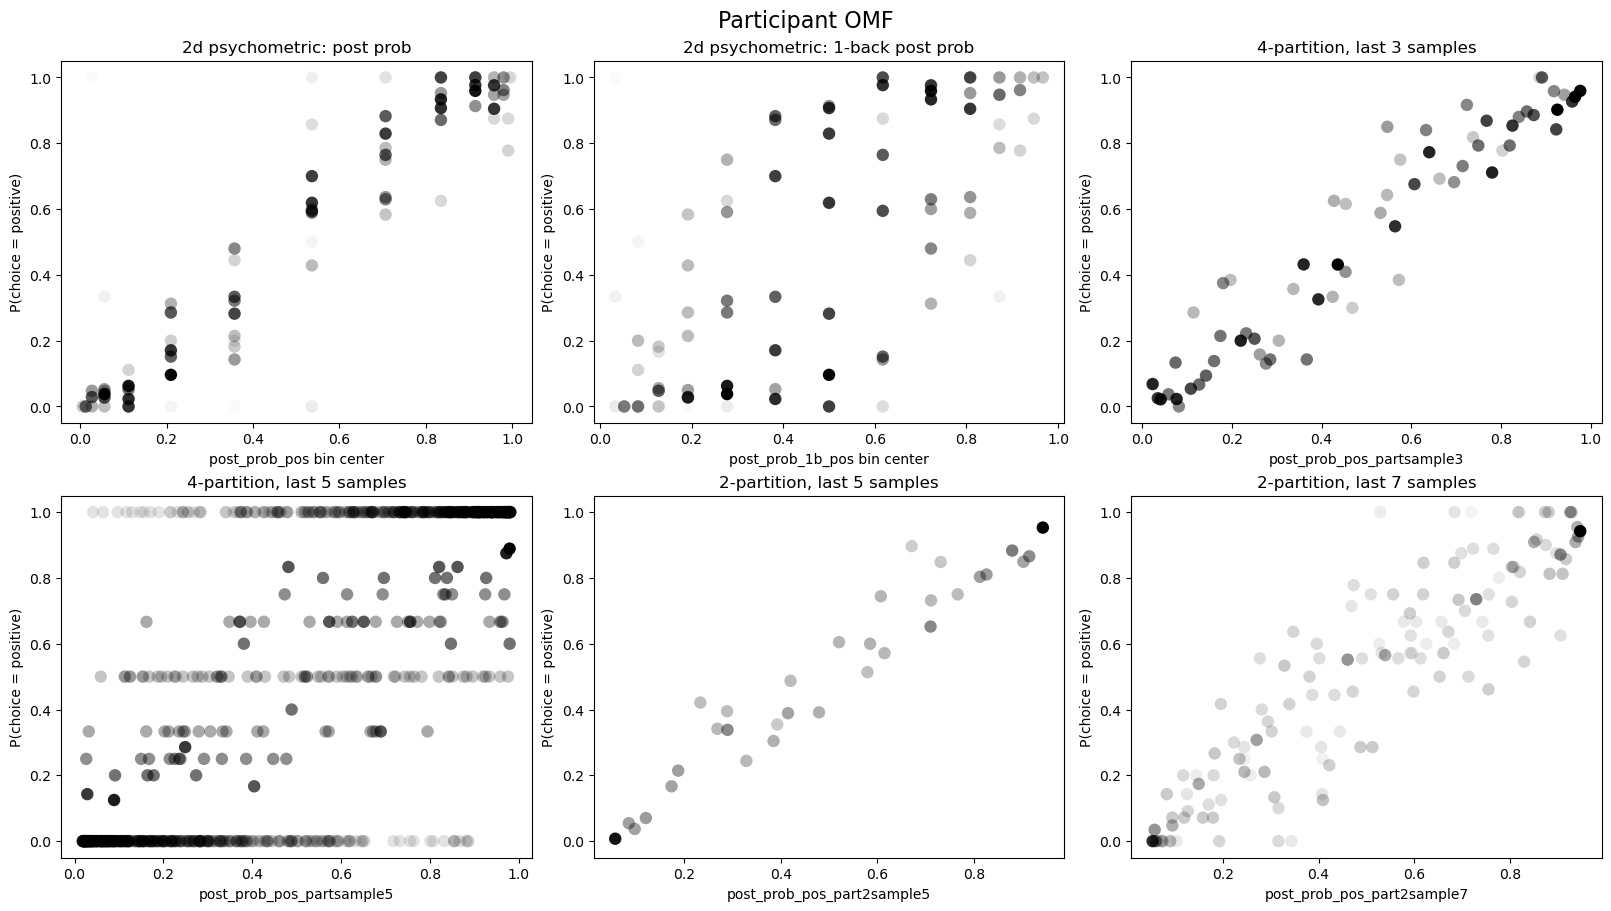

Processing PDP...


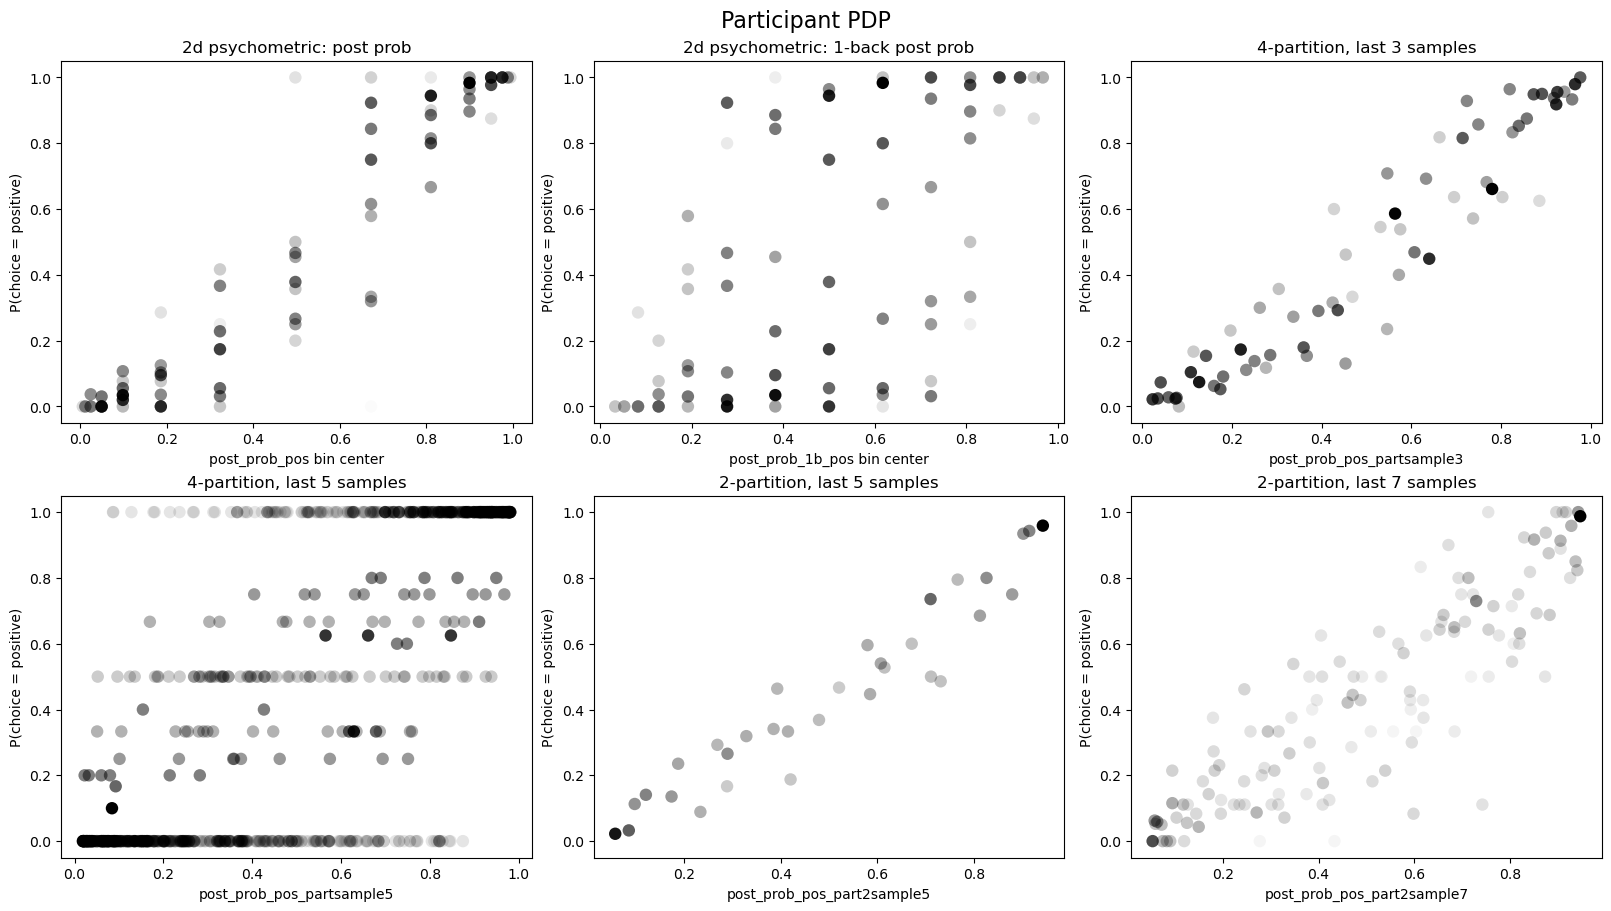

Processing QNV...


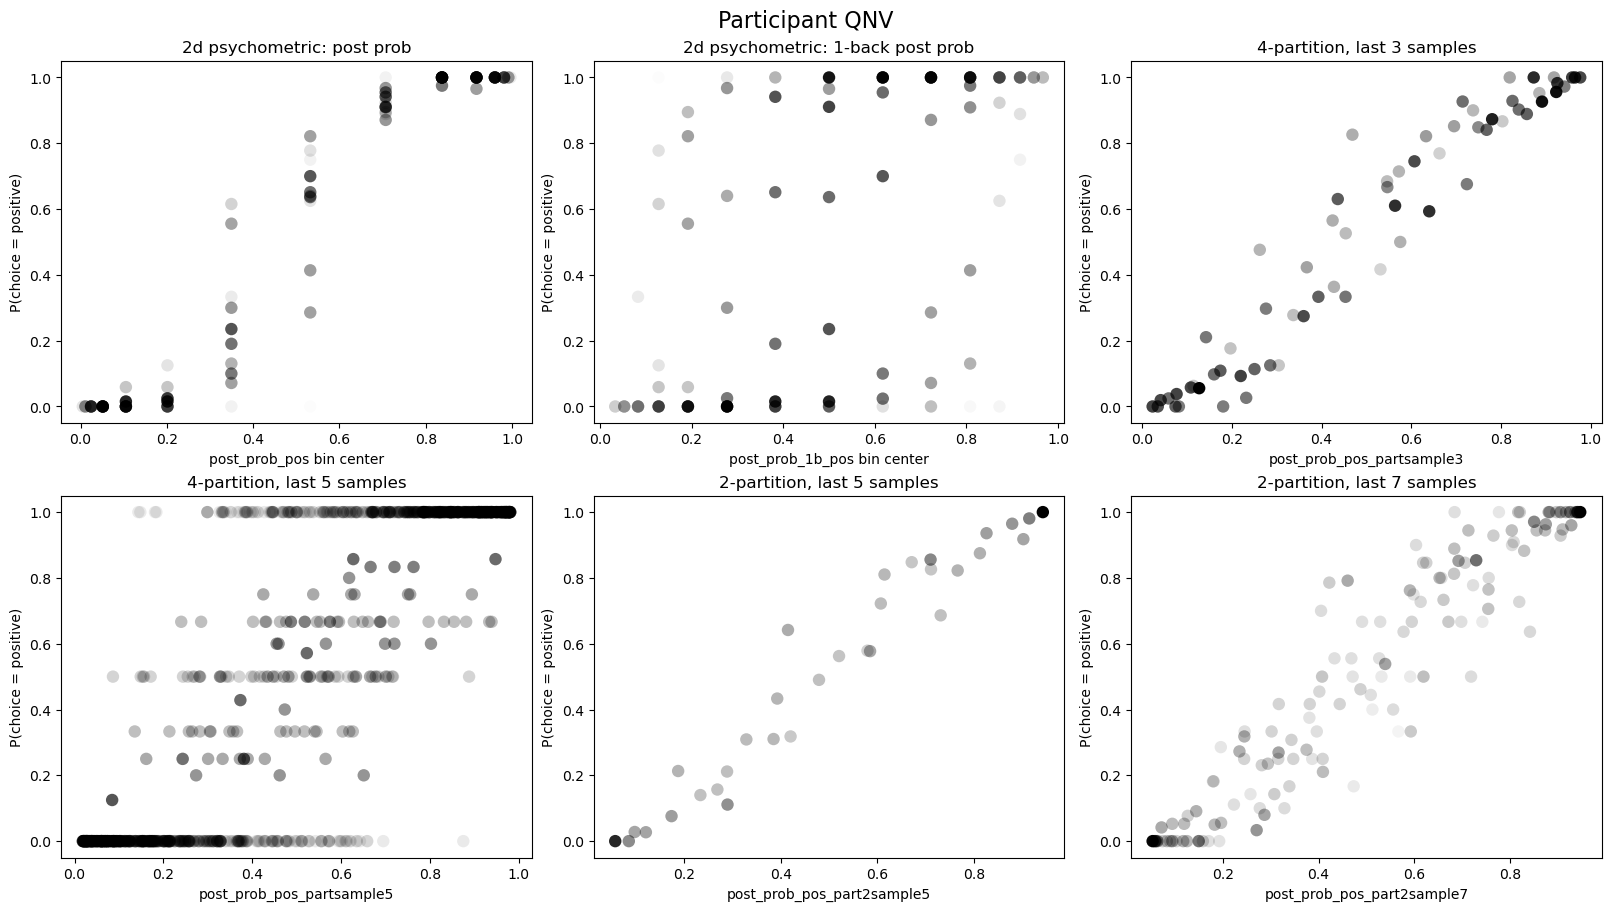

Processing TFD...


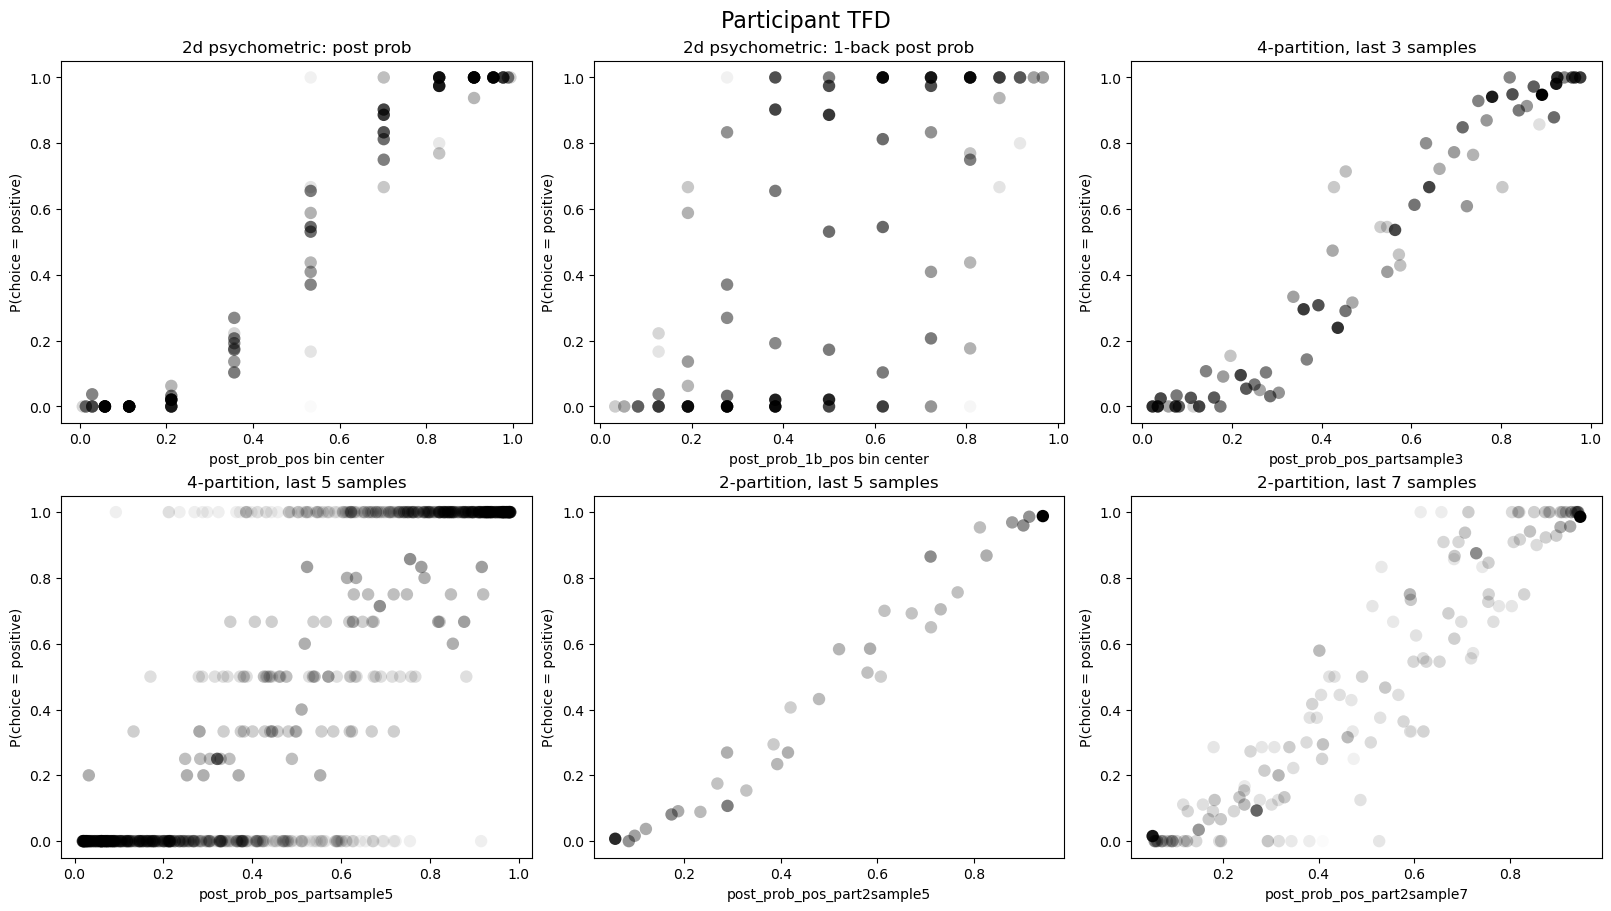

Processing TNB...


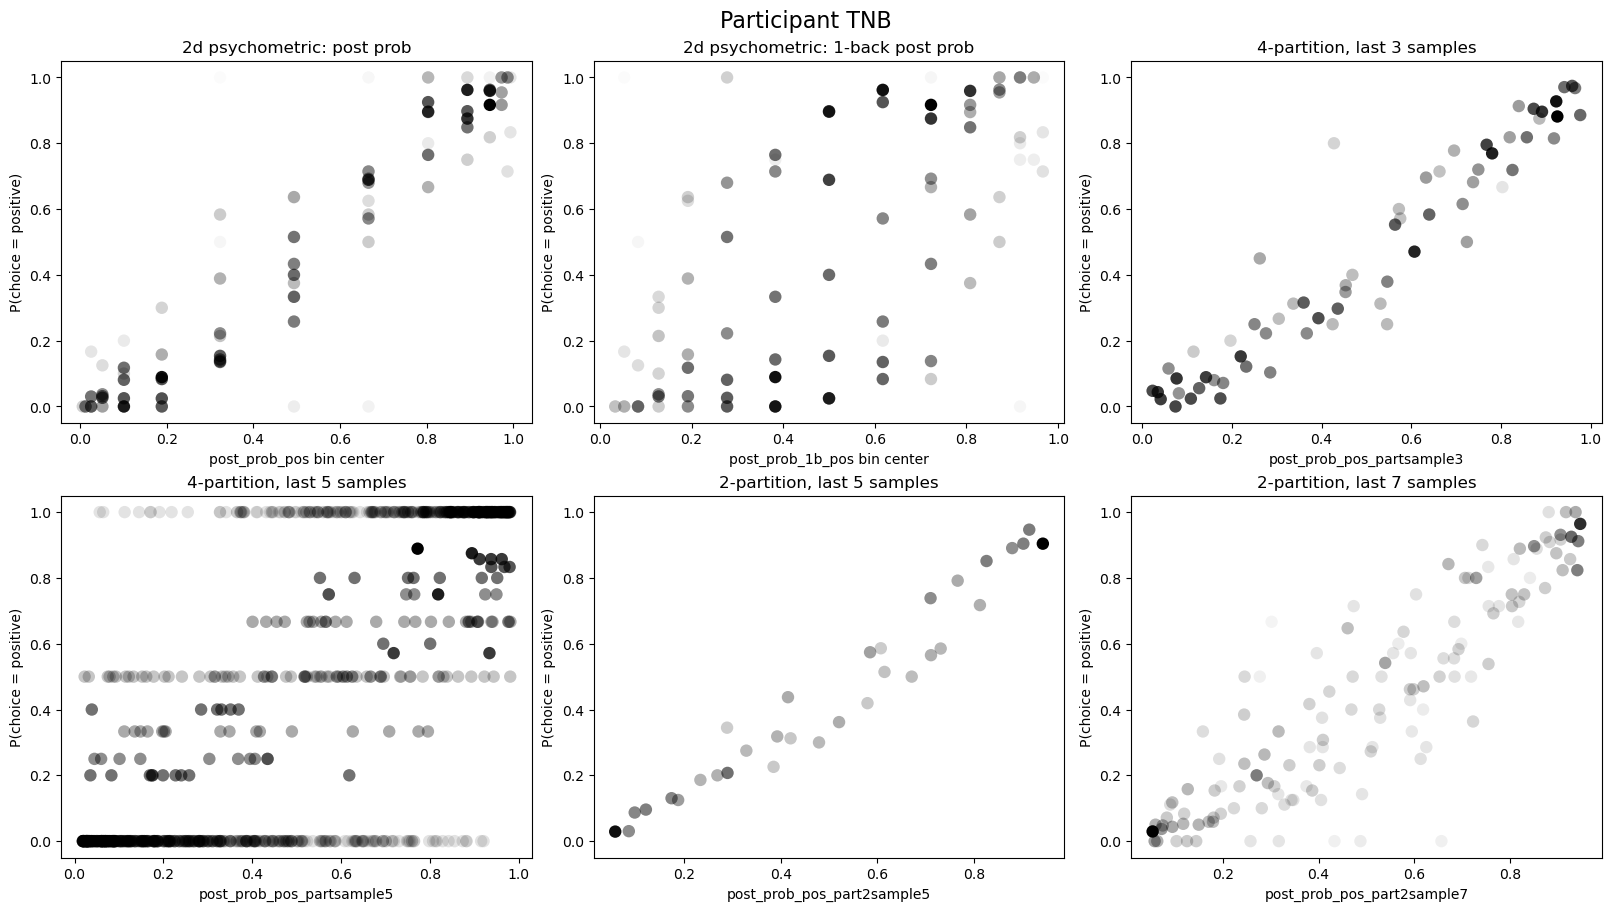

Processing TSJ...


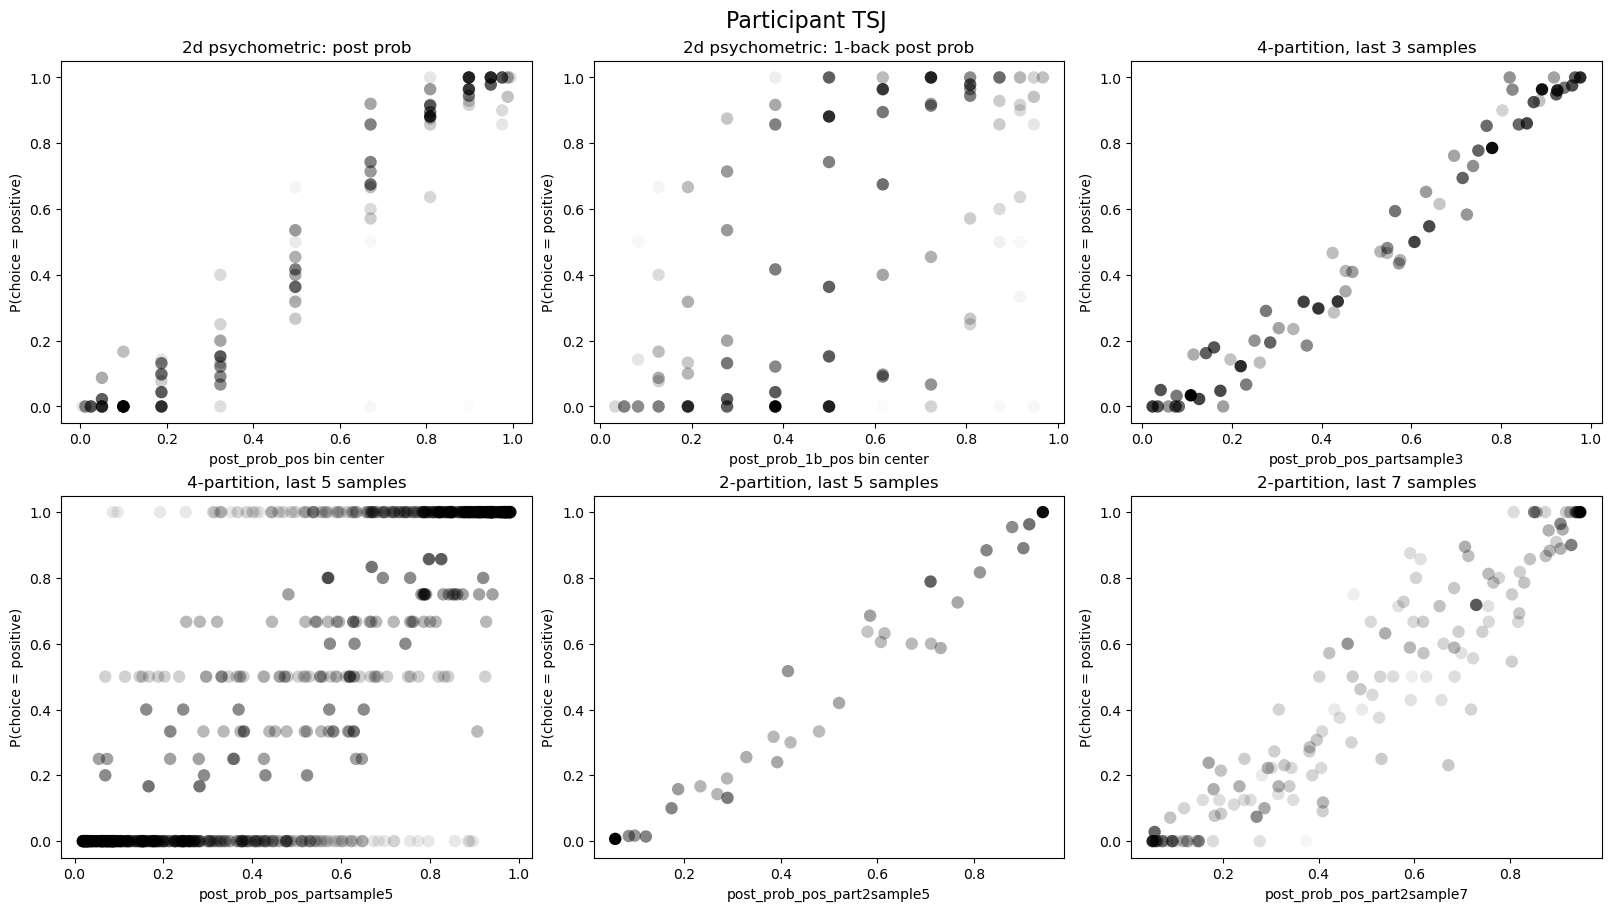

In [12]:
for participant_id in participants_no_2:
    print(f"Processing {participant_id}...")
    trials_df, samples_df, block_metadata_df = prepare_subject_data(participant_id)
    fig, axes = plot_subject_psychometrics(trials_df, participant_id)
    plt.show()


## Posterior-specific simulated behavior

This section uses the DCB trial set as a common stimulus/trial scaffold. For each posterior-probability type, it simulates choices from a beta-softmax policy driven only by that posterior, then re-runs the same six psychometric-function plots on the simulated choices.


In [17]:
SIMULATION_BETA = 6
SIMULATION_SEED = None  # Set to an integer for reproducible simulations
SIMULATION_PARTICIPANT = "DCB"

BEHAVIOR_TYPES = [
    {
        "name": "full posterior",
        "posterior_col": "post_prob_pos",
        "plot_label": "post_prob_pos",
    },
    {
        "name": "1-back posterior",
        "posterior_col": "post_prob_1b_pos",
        "plot_label": "post_prob_1b_pos",
    },
    {
        "name": "4-partition, last 3 samples posterior",
        "posterior_col": "post_prob_pos_partsample3",
        "plot_label": "post_prob_pos_partsample3",
    },
    {
        "name": "4-partition, last 5 samples posterior",
        "posterior_col": "post_prob_pos_partsample5",
        "plot_label": "post_prob_pos_partsample5",
    },
    {
        "name": "2-partition, last 5 samples posterior",
        "posterior_col": "post_prob_pos_part2sample5",
        "plot_label": "post_prob_pos_part2sample5",
    },
    {
        "name": "2-partition, last 7 samples posterior",
        "posterior_col": "post_prob_pos_part2sample7",
        "plot_label": "post_prob_pos_part2sample7",
    },
]


def softmax_positive_choice_probability(posterior_pos, beta=SIMULATION_BETA):
    posterior_pos = np.asarray(posterior_pos, dtype=float)
    utilities = np.column_stack((posterior_pos, 1 - posterior_pos))
    scaled_utilities = beta * utilities
    scaled_utilities = scaled_utilities - np.nanmax(scaled_utilities, axis=1, keepdims=True)
    exp_utilities = np.exp(scaled_utilities)
    return exp_utilities[:, 0] / exp_utilities.sum(axis=1)


def simulate_choices_from_posterior(trials_df, posterior_col, beta=SIMULATION_BETA, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    simulated_df = trials_df.copy()
    p_choose_positive = softmax_positive_choice_probability(simulated_df[posterior_col], beta=beta)
    finite_mask = np.isfinite(p_choose_positive)

    simulated_response = np.full(len(simulated_df), np.nan)
    simulated_response[finite_mask] = (
        rng.random(np.count_nonzero(finite_mask)) < p_choose_positive[finite_mask]
    ).astype(float)

    simulated_df["response"] = simulated_response
    simulated_df["sim_p_choose_positive"] = p_choose_positive
    simulated_df["sim_modulating_posterior"] = posterior_col
    return simulated_df


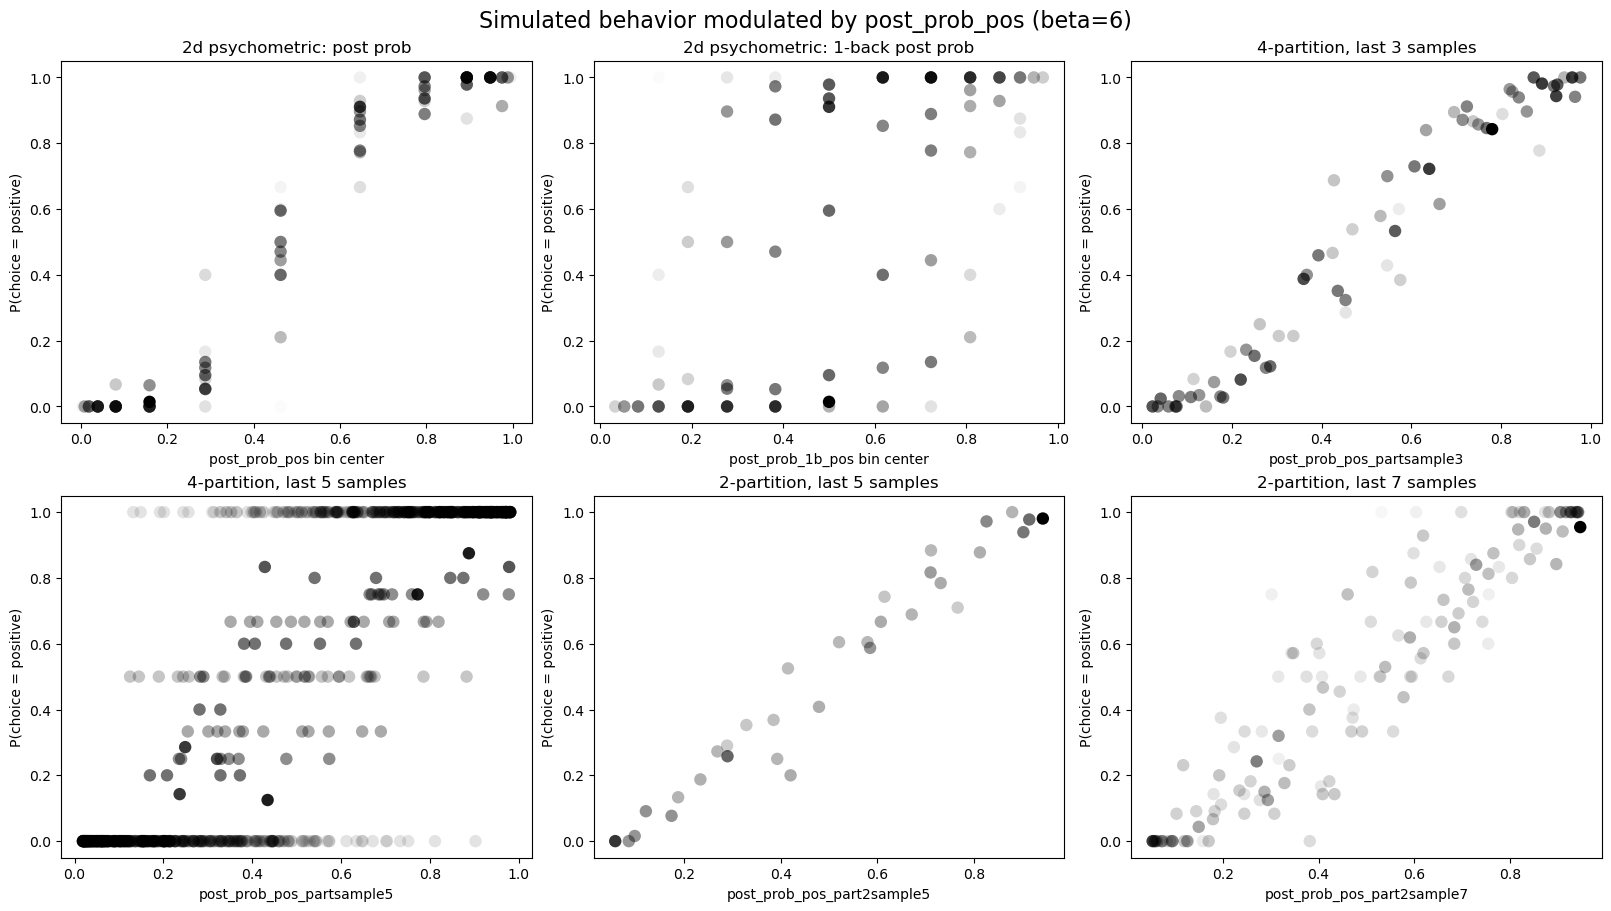

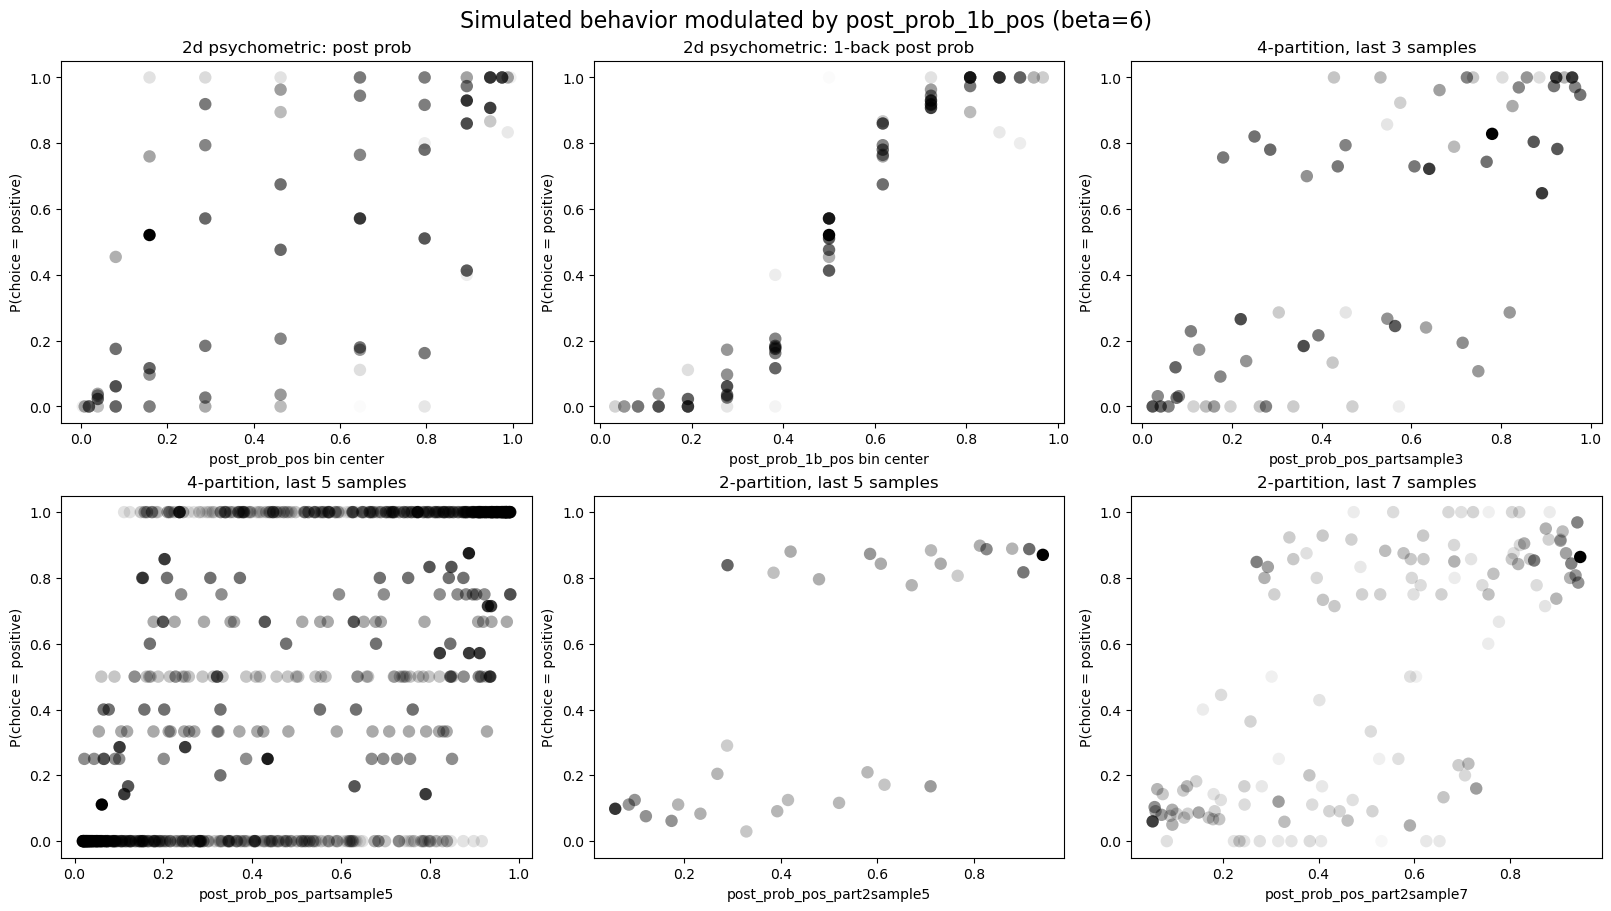

C:\Users\parja\AppData\Local\Temp\ipykernel_64108\3554008980.py:43: RuntimeWarning: All-NaN slice encountered
  scaled_utilities = scaled_utilities - np.nanmax(scaled_utilities, axis=1, keepdims=True)


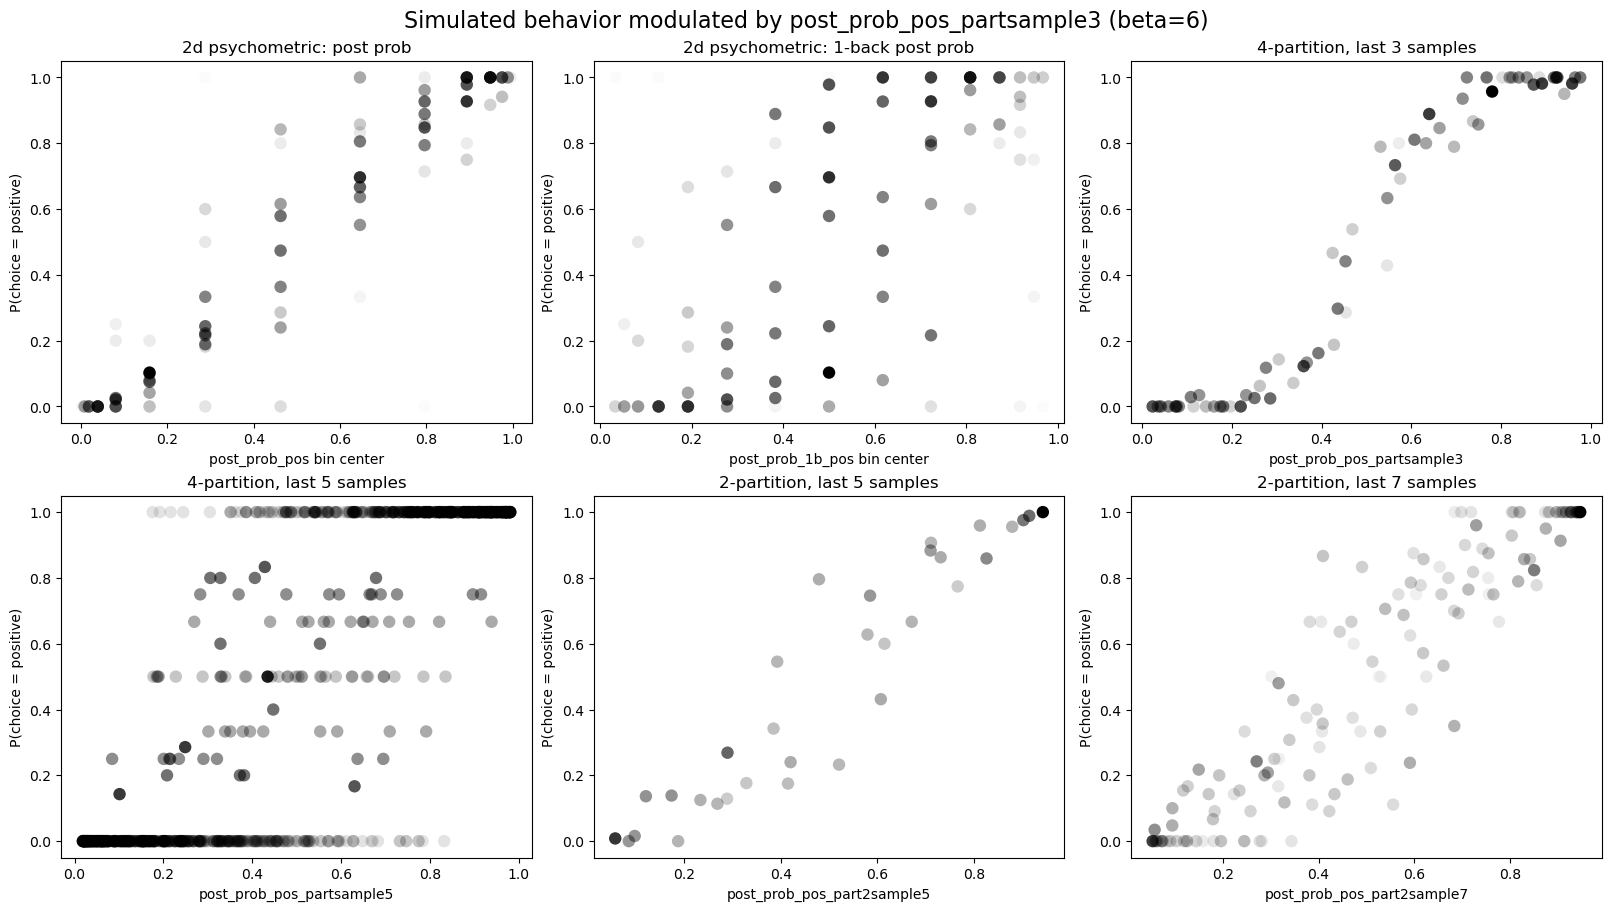

C:\Users\parja\AppData\Local\Temp\ipykernel_64108\3554008980.py:43: RuntimeWarning: All-NaN slice encountered
  scaled_utilities = scaled_utilities - np.nanmax(scaled_utilities, axis=1, keepdims=True)


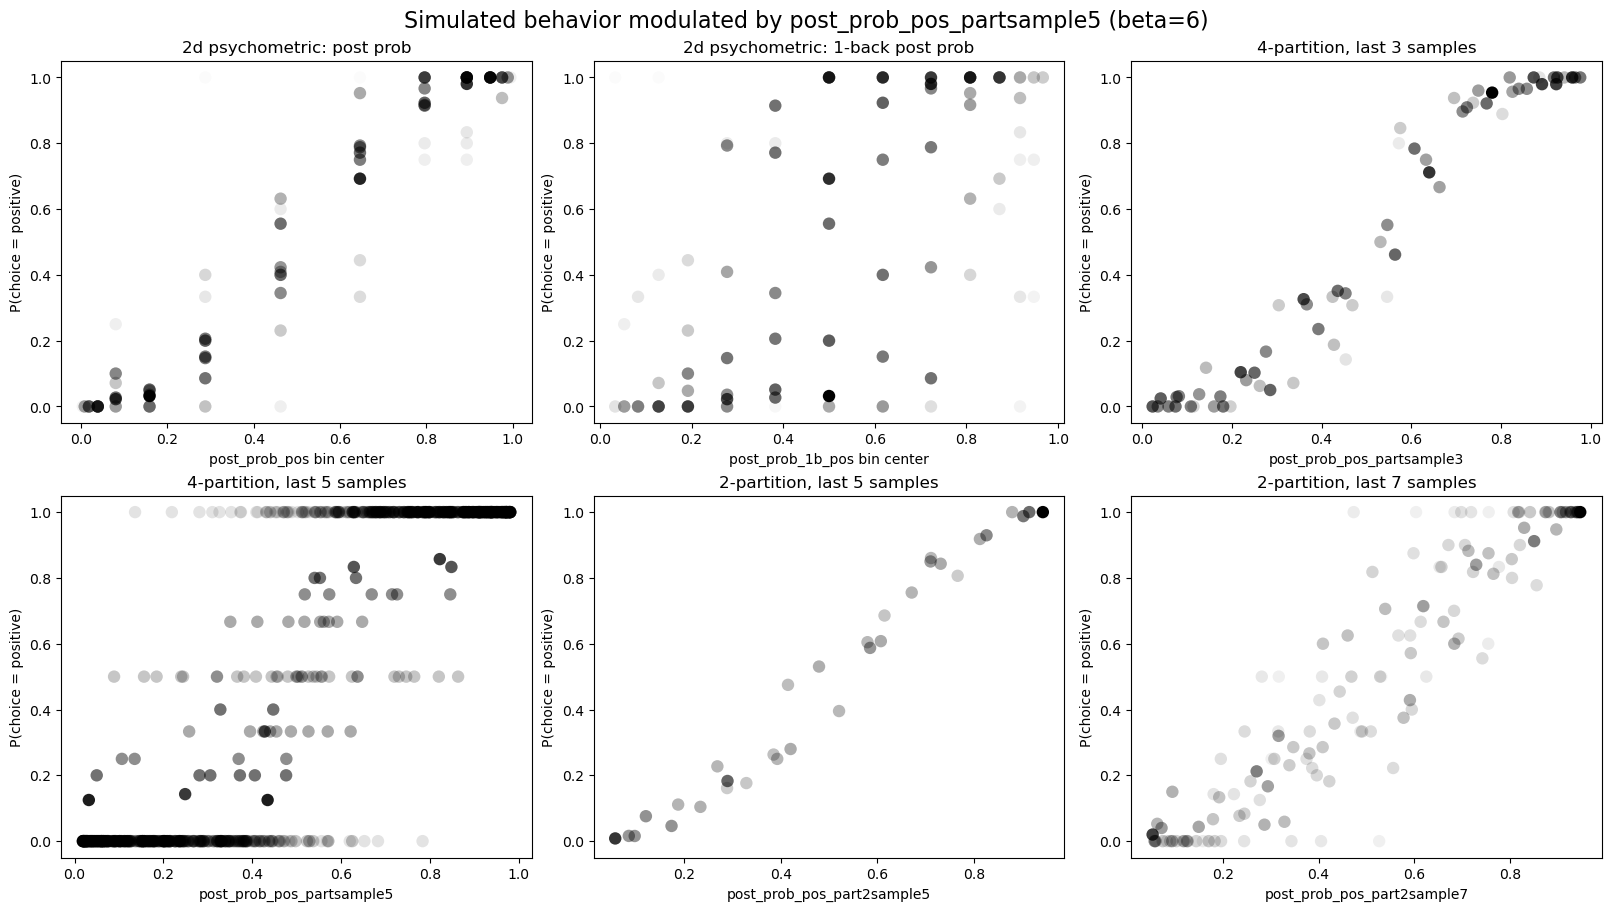

C:\Users\parja\AppData\Local\Temp\ipykernel_64108\3554008980.py:43: RuntimeWarning: All-NaN slice encountered
  scaled_utilities = scaled_utilities - np.nanmax(scaled_utilities, axis=1, keepdims=True)


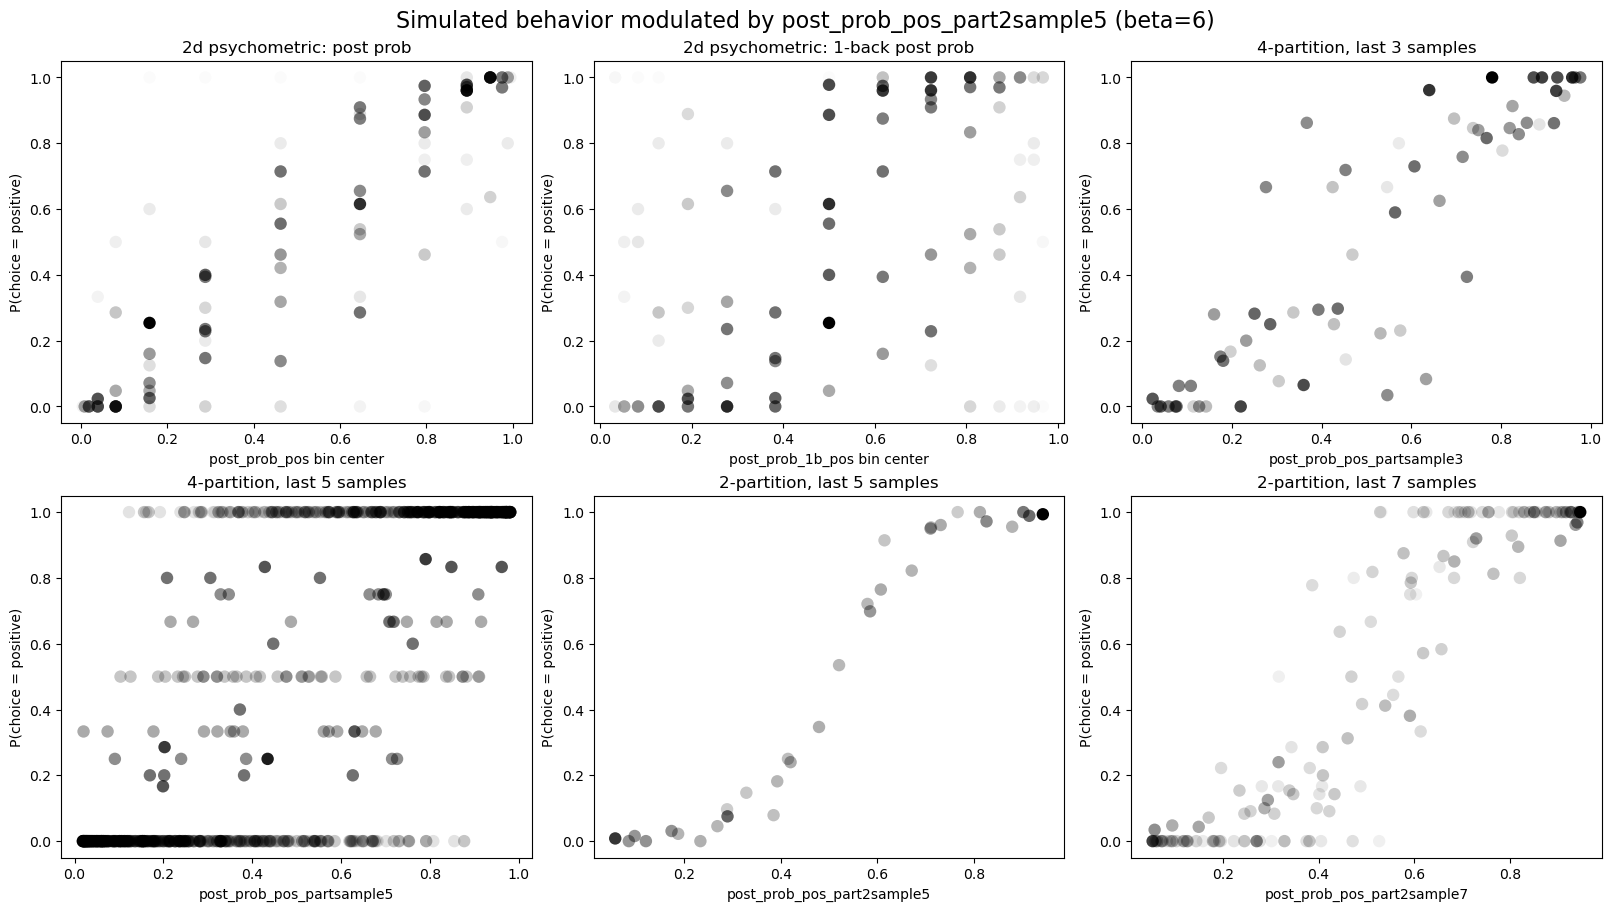

C:\Users\parja\AppData\Local\Temp\ipykernel_64108\3554008980.py:43: RuntimeWarning: All-NaN slice encountered
  scaled_utilities = scaled_utilities - np.nanmax(scaled_utilities, axis=1, keepdims=True)


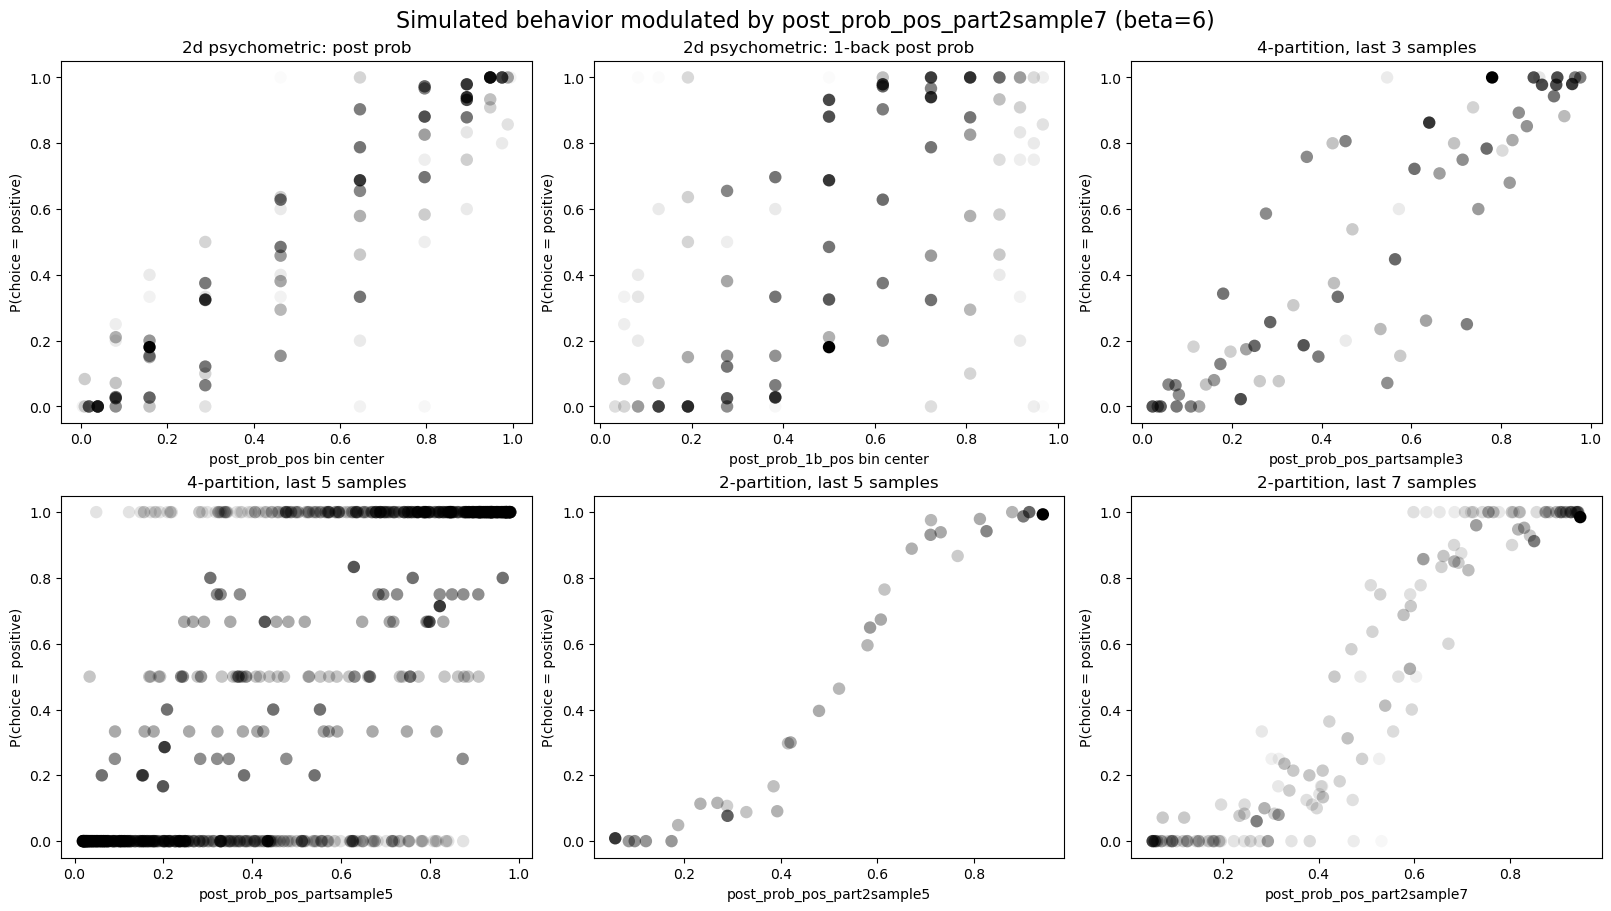

In [18]:
dcb_trials_df, dcb_samples_df, dcb_block_metadata_df = prepare_subject_data(SIMULATION_PARTICIPANT)
simulation_rng = np.random.default_rng(SIMULATION_SEED)
simulated_behavior_results = {}

for behavior_type in BEHAVIOR_TYPES:
    posterior_col = behavior_type["posterior_col"]
    simulated_trials_df = simulate_choices_from_posterior(
        dcb_trials_df,
        posterior_col,
        beta=SIMULATION_BETA,
        rng=simulation_rng,
    )
    simulated_behavior_results[posterior_col] = simulated_trials_df

    fig, axes = plot_subject_psychometrics(
        simulated_trials_df,
        f"{SIMULATION_PARTICIPANT} simulated: {behavior_type['name']}",
    )
    fig.suptitle(
        f"Simulated behavior modulated by {behavior_type['plot_label']} (beta={SIMULATION_BETA})",
        fontsize=16,
    )
    plt.show()
